# B2B Sales Performance & Pipeline Analysis

**A CRM opportunity-level analysis of pipeline health, conversion, product performance, and sales-team effectiveness.**

## Business Objective

A B2B sales organization needs to understand how its pipeline is performing: how much revenue is being realized, how efficiently opportunities convert into closed business, and where performance varies by product, sales team, region, customer segment, and time. This notebook analyzes CRM opportunity data end-to-end — from raw data through cleaning, modeling, KPI design, exploratory analysis, SQL validation, and an executive summary — to answer that question with reproducible, auditable evidence.

## Key Business Questions

1. How much revenue is being generated, and how efficiently does the pipeline convert?
2. Which products perform best, and by what measure (volume, conversion, or deal value)?
3. Which sales agents, managers, and regions perform best — and through what mechanism?
4. How do customer account size and sector relate to revenue outcomes?
5. How does performance change over time, and how does sales-cycle length relate to win rate?
6. Where are the clearest, evidence-backed opportunities to improve revenue?

## Analytical Approach

Each major section follows the same structure: **Business Question → Analysis → Result → Interpretation**. Findings are kept separate from interpretation, and interpretation is kept separate from recommendation — see the Executive Summary (Part 8) for how these are distinguished.

## Tools

Python (pandas, numpy, matplotlib, seaborn) for cleaning, modeling, and exploratory analysis; SQLite/SQL for a parallel, validated query layer; Data Studio (formerly Looker Studio) for the interactive dashboard.

## Data Sources

Four CRM extracts covering opportunities engaged between **October 2016 and December 2017**:

| File | Grain | Rows | Description |
|---|---|---|---|
| `sales_pipeline.csv` | 1 row per opportunity | 8,800 | Opportunity-level CRM pipeline: agent, product, account, stage, dates, close value |
| `accounts.csv` | 1 row per customer account | 85 | Customer firmographics: sector, size, location, revenue |
| `products.csv` | 1 row per product | 7 | Product catalog: series and list price |
| `sales_teams.csv` | 1 row per sales agent | 35 | Org structure: agent → manager → regional office |

All four files are read directly from this repository's root folder (flat structure, no subfolders) so the notebook runs unmodified after a `git clone`.

---
# Part 1 — Data Overview & Quality Assessment

**Business question:** What data do we actually have, and can it be trusted for analysis?

Before any cleaning or analysis, we inventory all four source tables, check their structure, and identify concrete data-quality issues (missing values, duplicates, mismatched keys, inconsistent categories) that must be resolved in Part 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
# 1.1 — Load raw source data
accounts = pd.read_csv("accounts.csv")
products = pd.read_csv("products.csv")
sales_pipeline = pd.read_csv("sales_pipeline.csv")
sales_teams = pd.read_csv("sales_teams.csv")

print("Accounts:      ", accounts.shape)
print("Products:      ", products.shape)
print("Sales Pipeline:", sales_pipeline.shape)
print("Sales Teams:   ", sales_teams.shape)

Accounts:       (85, 7)
Products:       (7, 3)
Sales Pipeline: (8800, 8)
Sales Teams:    (35, 3)


In [3]:
# 1.2 — Structural overview
sales_pipeline.info()

<class 'pandas.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   str    
 1   sales_agent     8800 non-null   str    
 2   product         8800 non-null   str    
 3   account         7375 non-null   str    
 4   deal_stage      8800 non-null   str    
 5   engage_date     8300 non-null   str    
 6   close_date      6711 non-null   str    
 7   close_value     6711 non-null   float64
dtypes: float64(1), str(7)
memory usage: 550.1 KB


In [4]:
accounts.head()

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


In [5]:
sales_pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


In [6]:
# 1.3 — Missing-value assessment (pipeline table)
sales_pipeline.isna().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

In [7]:
# 1.4 — Duplicate and uniqueness checks across all four tables
print("Accounts duplicates:      ", accounts.duplicated().sum())
print("Products duplicates:      ", products.duplicated().sum())
print("Sales Pipeline duplicates:", sales_pipeline.duplicated().sum())
print("Sales Teams duplicates:   ", sales_teams.duplicated().sum())
print("Opportunity IDs unique:   ", sales_pipeline["opportunity_id"].is_unique)

Accounts duplicates:       0
Products duplicates:       0
Sales Pipeline duplicates: 0
Sales Teams duplicates:    0
Opportunity IDs unique:    True


In [8]:
# 1.5 — Referential integrity: do pipeline foreign keys match their lookup tables?
print("Agents in pipeline but not in sales_teams:")
print(set(sales_pipeline["sales_agent"].unique()) - set(sales_teams["sales_agent"].unique()))

print("\nAccounts in pipeline but not in accounts table:")
print(set(sales_pipeline["account"].dropna().unique()) - set(accounts["account"].dropna().unique()))

print("\nProducts in pipeline but not in products table:")
print(set(sales_pipeline["product"].unique()) - set(products["product"].unique()))

Agents in pipeline but not in sales_teams:
set()

Accounts in pipeline but not in accounts table:
set()

Products in pipeline but not in products table:
{'GTXPro'}


In [9]:
# Category cleanliness check on the accounts lookup table
accounts["sector"].value_counts(dropna=False)

sector
retail                17
technolgy             12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64

In [10]:
# 1.6 — Are missing engage/close dates and missing account keys random, or structural?
sp = sales_pipeline.copy()
sp["engage_date"] = pd.to_datetime(sp["engage_date"], errors="coerce")
sp["close_date"] = pd.to_datetime(sp["close_date"], errors="coerce")

print("Missing engage_date by deal_stage:")
print(pd.crosstab(sp["deal_stage"], sp["engage_date"].isna(), margins=True))

print("\nMissing close_date by deal_stage:")
print(pd.crosstab(sp["deal_stage"], sp["close_date"].isna(), margins=True))

print("\nMissing account by deal_stage:")
print(pd.crosstab(sp["deal_stage"], sp["account"].isna(), margins=True))

Missing engage_date by deal_stage:
engage_date  False  True   All
deal_stage                    
Engaging      1589     0  1589
Lost          2473     0  2473
Prospecting      0   500   500
Won           4238     0  4238
All           8300   500  8800

Missing close_date by deal_stage:
close_date   False  True   All
deal_stage                    
Engaging         0  1589  1589
Lost          2473     0  2473
Prospecting      0   500   500
Won           4238     0  4238
All           6711  2089  8800

Missing account by deal_stage:
account      False  True   All
deal_stage                    
Engaging       501  1088  1589
Lost          2473     0  2473
Prospecting    163   337   500
Won           4238     0  4238
All           7375  1425  8800


In [11]:
# How close_value behaves across deal stages
sp.groupby("deal_stage")["close_value"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
deal_stage,,,,,
Engaging,0,NaN,NaN,NaN,NaN
Lost,2473,0.000000,0.0,0.0,0.0
Prospecting,0,NaN,NaN,NaN,NaN
Won,4238,2360.909391,1117.0,38.0,30288.0


In [12]:
print("Engage date range:", sp["engage_date"].min(), "->", sp["engage_date"].max())
print("Close date range: ", sp["close_date"].min(), "->", sp["close_date"].max())

Engage date range: 2016-10-20 00:00:00 -> 2017-12-27 00:00:00
Close date range:  2017-03-01 00:00:00 -> 2017-12-31 00:00:00


### 1.7 Data Quality Findings

**Observed (facts from the checks above):**

- No duplicate rows in any of the four tables, and `opportunity_id` is 100% unique (8,800 of 8,800) — safe to use as the analytical grain.
- One product-name mismatch: `"GTXPro"` appears in the pipeline but not in the product catalog (catalog has `"GTX Pro"`) — a data-entry typo, not a genuinely new product.
- One sector-label typo in the accounts table: `"technolgy"` (12 accounts) should be `"technology"`.
- All `sales_agent` and `account` keys in the pipeline otherwise match their lookup tables exactly — no orphaned foreign keys beyond the product typo above.
- Missing values are **structural, not random**, and line up exactly with the sales process:
  - `engage_date` is missing only for `Prospecting` opportunities (500 rows) — these haven't been actively engaged yet.
  - `close_date` and `close_value` are missing only for still-open opportunities (`Prospecting` + `Engaging`, 2,089 rows) — they haven't closed yet.
  - `account` is missing for 1,425 rows, concentrated in `Prospecting` and `Engaging` — some opportunities are created before a customer account record exists.
  - For **Lost** opportunities, `close_value` is recorded as `0`, not missing — a Lost deal has a real close event with zero realized value. This distinction matters: any "average deal size" calculation must explicitly filter to `deal_stage == "Won"`, or it will silently average in these zeros.
- The dataset spans opportunities engaged between **2016-10-20 and 2017-12-27**, with closes between **2017-03-01 and 2017-12-31**. Because engagement only starts in October 2016, very few opportunities have had time to reach a Q1-2017 close — this partial first quarter is a limitation carried through the rest of the analysis (see Part 8).

These findings directly drive the cleaning steps in Part 2.

---
# Part 2 — Data Cleaning & Preparation

**Business question:** How do we turn the raw extracts into an analysis-ready dataset without distorting the underlying business reality?

Every transformation below is a direct response to a finding from Part 1 — nothing is cleaned "just in case."

In [13]:
# 2.1 — Standardize column names and text fields
df = sales_pipeline.copy()
accounts_clean = accounts.copy()
products_clean = products.copy()
sales_teams_clean = sales_teams.copy()

for frame in [df, accounts_clean, products_clean, sales_teams_clean]:
    frame.columns = frame.columns.str.strip().str.lower().str.replace(" ", "_")

df["engage_date"] = pd.to_datetime(df["engage_date"], errors="coerce")
df["close_date"] = pd.to_datetime(df["close_date"], errors="coerce")

for col in ["sales_agent", "product", "account", "deal_stage"]:
    df[col] = df[col].astype("string").str.strip()

for col in ["sales_agent", "manager", "regional_office"]:
    sales_teams_clean[col] = sales_teams_clean[col].astype("string").str.strip()
for col in products_clean.columns:
    if products_clean[col].dtype == "object" or str(products_clean[col].dtype) == "string":
        products_clean[col] = products_clean[col].astype("string").str.strip()
for col in accounts_clean.columns:
    if accounts_clean[col].dtype == "object" or str(accounts_clean[col].dtype) == "string":
        accounts_clean[col] = accounts_clean[col].astype("string").str.strip()

In [14]:
# 2.2 — Fix the product-name typo identified in Part 1
df["product"] = df["product"].replace({"GTXPro": "GTX Pro"})

# Confirm the mismatch is resolved
print("Remaining product mismatches:", set(df["product"].unique()) - set(products_clean["product"].unique()))

Remaining product mismatches: set()


In [15]:
# 2.3 — Fix the sector-label typo identified in Part 1
accounts_clean["sector"] = accounts_clean["sector"].replace({"technolgy": "technology"})
accounts_clean["sector"].value_counts()

sector
retail                17
technology            12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64

In [16]:
# 2.4 — Sanity checks before feature engineering
print("Impossible date sequences (close before engage):",
      (df["close_date"].notna() & df["engage_date"].notna() & (df["close_date"] < df["engage_date"])).sum())
print("Duplicate opportunity IDs:", df["opportunity_id"].duplicated().sum())
print("Negative close values:", (df["close_value"] < 0).sum())

Impossible date sequences (close before engage): 0
Duplicate opportunity IDs: 0
Negative close values: 0


In [17]:
# 2.5 — Engineer business flags directly from deal_stage
df["won_flag"] = np.where(df["deal_stage"] == "Won", 1, 0)
df["lost_flag"] = np.where(df["deal_stage"] == "Lost", 1, 0)
df["open_flag"] = np.where(df["deal_stage"].isin(["Prospecting", "Engaging"]), 1, 0)

df["pipeline_status"] = np.select(
    [df["deal_stage"].eq("Won"), df["deal_stage"].eq("Lost"),
     df["deal_stage"].isin(["Prospecting", "Engaging"])],
    ["Won", "Lost", "Open"],
    default="Other"
)

df["pipeline_status"].value_counts()

pipeline_status
Won     4238
Lost    2473
Open    2089
Name: count, dtype: int64

In [18]:
# 2.6 — Engineer sales-cycle length and time dimensions
df["sales_cycle_days"] = (df["close_date"] - df["engage_date"]).dt.days

df["engage_year"] = df["engage_date"].dt.year
df["engage_month"] = df["engage_date"].dt.month
df["engage_quarter"] = df["engage_date"].dt.to_period("Q").astype("string")

df["close_year"] = df["close_date"].dt.year
df["close_month"] = df["close_date"].dt.month
df["close_quarter"] = df["close_date"].dt.to_period("Q").astype("string")

print("Negative sales-cycle values:", (df["sales_cycle_days"] < 0).sum())
df["sales_cycle_days"].describe()

Negative sales-cycle values: 0


count    6711.000000
mean       47.985397
std        41.057665
min         1.000000
25%         8.000000
50%        45.000000
75%        85.000000
max       138.000000
Name: sales_cycle_days, dtype: float64

In [19]:
# 2.7 — Final cleaning validation
print("Duplicate opportunity IDs:", df["opportunity_id"].duplicated().sum())
print("Negative sales cycles:", (df["sales_cycle_days"] < 0).sum())
print("\nPipeline status counts:")
print(df["pipeline_status"].value_counts())
print("\nFinal column list:")
print(df.columns.tolist())

Duplicate opportunity IDs: 0
Negative sales cycles: 0

Pipeline status counts:
pipeline_status
Won     4238
Lost    2473
Open    2089
Name: count, dtype: int64

Final column list:
['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value', 'won_flag', 'lost_flag', 'open_flag', 'pipeline_status', 'sales_cycle_days', 'engage_year', 'engage_month', 'engage_quarter', 'close_year', 'close_month', 'close_quarter']


In [20]:
# 2.8 — Persist cleaned tables (flat structure, repo root)
df.to_csv("sales_pipeline_clean.csv", index=False)
accounts_clean.to_csv("accounts_clean.csv", index=False)
products_clean.to_csv("products_clean.csv", index=False)
sales_teams_clean.to_csv("sales_teams_clean.csv", index=False)

print("Cleaned files written:")
for f in ["sales_pipeline_clean.csv", "accounts_clean.csv", "products_clean.csv", "sales_teams_clean.csv"]:
    print(" -", f)

Cleaned files written:
 - sales_pipeline_clean.csv
 - accounts_clean.csv
 - products_clean.csv
 - sales_teams_clean.csv


### Data Cleaning Summary

- Standardized column names and stripped whitespace from all text fields across all four tables.
- Corrected two source-data typos: `"GTXPro"` → `"GTX Pro"` (pipeline) and `"technolgy"` → `"technology"` (accounts). No other categorical inconsistencies were found.
- Confirmed zero duplicate rows, zero duplicate opportunity IDs, zero negative sales cycles, and zero impossible date sequences (close before engage) — the source data required no rows to be dropped.
- Engineered three mutually exclusive status flags (`won_flag`, `lost_flag`, `open_flag`) and a single `pipeline_status` field directly from `deal_stage`, so all later aggregations use one consistent definition of Won/Lost/Open.
- Engineered `sales_cycle_days` and calendar dimensions (`engage_quarter`, `close_quarter`, etc.) needed for the time-based analysis in Part 5.5.
- **No rows were removed or imputed.** Missing values (`engage_date`, `close_date`, `close_value`, `account`) are left as `NaN` because — per the Part 1 findings — they are structural (a natural consequence of an opportunity's current stage), not data-entry errors. Filling them would misrepresent open pipeline as closed business.

---
# Part 3 — Data Modeling: Building the Master Analytical Table

**Business question:** How do we combine four separate CRM tables into one analysis-ready table without losing, duplicating, or silently mismatching any opportunity?

The pipeline table is the fact table (grain: one row per opportunity). Products, sales teams, and accounts are lookup ("dimension") tables joined onto it with `LEFT JOIN` semantics, so that **every opportunity is preserved** even where a dimension can't be matched (e.g. an opportunity with no linked account yet).

In [21]:
# 3.1 — Reload cleaned tables from disk (guarantees the model starts from a clean, saved state)
pipeline = pd.read_csv("sales_pipeline_clean.csv", parse_dates=["engage_date", "close_date"])
accounts_clean = pd.read_csv("accounts_clean.csv")
products_clean = pd.read_csv("products_clean.csv")
sales_teams_clean = pd.read_csv("sales_teams_clean.csv")

print("Pipeline:   ", pipeline.shape)
print("Accounts:   ", accounts_clean.shape)
print("Products:   ", products_clean.shape)
print("Sales Teams:", sales_teams_clean.shape)

print("\nDuplicate join keys — accounts:", accounts_clean["account"].duplicated().sum())
print("Duplicate join keys — products:", products_clean["product"].duplicated().sum())
print("Duplicate join keys — agents:  ", sales_teams_clean["sales_agent"].duplicated().sum())

Pipeline:    (8800, 19)
Accounts:    (85, 7)
Products:    (7, 3)
Sales Teams: (35, 3)

Duplicate join keys — accounts: 0
Duplicate join keys — products: 0
Duplicate join keys — agents:   0


In [22]:
# 3.2 — Prepare dimension tables (rename ambiguous columns before merging)
accounts_model = accounts_clean.rename(columns={"revenue": "account_revenue"})
products_model = products_clean.copy()
teams_model = sales_teams_clean.copy()

In [23]:
# 3.3 — Sequential left joins, validating cardinality and row count at every step
master = pipeline.merge(products_model, on="product", how="left", validate="many_to_one")
print("After product join:  ", len(master), "rows |", master["sales_price"].isna().sum(), "unmatched")

master = master.merge(teams_model, on="sales_agent", how="left", validate="many_to_one")
print("After sales-team join:", len(master), "rows |", master["manager"].isna().sum(), "unmatched")

master = master.merge(accounts_model, on="account", how="left", validate="many_to_one")
print("After account join:  ", len(master), "rows |", master["sector"].isna().sum(), "unmatched (expected: opportunities with no linked account)")

After product join:   8800 rows | 0 unmatched
After sales-team join: 8800 rows | 0 unmatched
After account join:   8800 rows | 1425 unmatched (expected: opportunities with no linked account)


In [24]:
# 3.4 — Integrity tests: no opportunity gained, lost, or duplicated by the merges
original_ids = set(pipeline["opportunity_id"])
master_ids = set(master["opportunity_id"])

print("Row count preserved:        ", len(master) == len(pipeline))
print("Opportunities lost in merge:", len(original_ids - master_ids))
print("Duplicate IDs after merge:  ", master["opportunity_id"].duplicated().sum())
print("Unique opportunities:       ", master["opportunity_id"].nunique(), "/", len(master))

Row count preserved:         True
Opportunities lost in merge: 0
Duplicate IDs after merge:   0
Unique opportunities:        8800 / 8800


In [25]:
# 3.5 — Post-merge missing-value audit (this is where join-introduced nulls become visible)
missing_audit = master.isna().sum().reset_index()
missing_audit.columns = ["column", "missing_count"]
missing_audit["missing_pct"] = (missing_audit["missing_count"] / len(master) * 100).round(2)
missing_audit = missing_audit[missing_audit["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_audit

,column,missing_count,missing_pct
28,subsidiary_of,7508,85.32
17,close_month,2089,23.74
6,close_date,2089,23.74
12,sales_cycle_days,2089,23.74
7,close_value,2089,23.74
16,close_year,2089,23.74
18,close_quarter,2089,23.74
3,account,1425,16.19
23,sector,1425,16.19
24,year_established,1425,16.19


In [26]:
# 3.6 — Persist the master analytical table
master.to_csv("sales_analysis_master.csv", index=False)
print("Master table saved:", master.shape)
master.head()

Master table saved:

 (8800, 29)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,won_flag,lost_flag,open_flag,pipeline_status,sales_cycle_days,engage_year,engage_month,engage_quarter,close_year,close_month,close_quarter,series,sales_price,manager,regional_office,sector,year_established,account_revenue,employees,office_location,subsidiary_of
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,1,0,0,Won,132.0,2016.0,10.0,2016Q4,2017.0,3.0,2017Q1,GTX,1096,Dustin Brinkmann,Central,retail,2001.0,718.62,2448.0,United States,NaN
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0,1,0,0,Won,137.0,2016.0,10.0,2016Q4,2017.0,3.0,2017Q1,GTX,4821,Melvin Marxen,Central,medical,2002.0,3178.24,4540.0,United States,NaN
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,1,0,0,Won,133.0,2016.0,10.0,2016Q4,2017.0,3.0,2017Q1,MG,55,Melvin Marxen,Central,retail,2001.0,718.62,2448.0,United States,NaN
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,1,0,0,Won,135.0,2016.0,10.0,2016Q4,2017.0,3.0,2017Q1,GTX,550,Dustin Brinkmann,Central,software,1998.0,2714.90,2641.0,United States,Acme Corporation
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,1,0,0,Won,128.0,2016.0,10.0,2016Q4,2017.0,3.0,2017Q1,GTX,550,Summer Sewald,West,services,1982.0,792.46,1299.0,United States,NaN


### Data Model Notes

- **Grain:** one row per `opportunity_id`. All 8,800 opportunities are preserved through all three joins — no row was gained, lost, or duplicated.
- **Product** and **sales-team** joins match 100% (every pipeline `product` and `sales_agent` has a corresponding lookup record) because these are controlled, internal reference lists.
- **Account** join is intentionally a `LEFT JOIN`: 1,425 opportunities (16.2%) have no linked account, and after the join these rows correctly show `NaN` for `sector`, `account_revenue`, `employees`, `office_location`, and `subsidiary_of`. These opportunities remain fully valid for pipeline-level and product-level KPIs; they are simply excluded from account- and sector-level breakdowns (Section 5.4), where `.notna()` filters are applied explicitly.
- `subsidiary_of` is 85.3% missing — most accounts are not recorded as a subsidiary of another account. This field is not analytically useful at this level of missingness and is not used elsewhere in this notebook.
- `close_date`, `close_value`, `sales_cycle_days`, `close_year/month/quarter` are missing for the 2,089 still-open opportunities, exactly as expected from Part 1 — this is not a data-quality defect.

---
# Part 4 — KPI Definitions & Core Metrics

**Business question:** What is the single set of numbers everyone in the business should agree on before we look at any breakdown?

Every metric below is defined explicitly first, then calculated once, in Part 4 only. All later sections (Python EDA, SQL, dashboard) reuse these exact definitions rather than redefining them.

### KPI Definitions

| KPI | Definition |
|---|---|
| Total Opportunities | Count of unique `opportunity_id` |
| Won / Lost / Open Opportunities | Count where `pipeline_status` is `Won` / `Lost` / `Open` (`Open` = `Prospecting` + `Engaging`) |
| Closed Opportunities | Won + Lost |
| Closed Win Rate | Won ÷ Closed — **open opportunities are excluded**, since they have not yet had a chance to convert |
| Won Revenue | Sum of `close_value` where `deal_stage = 'Won'` |
| Average / Median Won Deal | Mean / median `close_value` **restricted to Won opportunities only** — Lost deals record `close_value = 0`, so including them would understate deal size |
| Average / Median Sales Cycle | Mean / median `sales_cycle_days` among **closed** (Won + Lost) opportunities — measures how long it takes the pipeline to resolve, either way |
| Average / Median Won Sales Cycle | Same, restricted to Won opportunities only — measures how long it takes to actually win a deal |

In [27]:
master = pd.read_csv("sales_analysis_master.csv", parse_dates=["engage_date", "close_date"])

total_opportunities = master["opportunity_id"].nunique()
won_opportunities = master["won_flag"].sum()
lost_opportunities = master["lost_flag"].sum()
open_opportunities = master["open_flag"].sum()
closed_opportunities = won_opportunities + lost_opportunities

win_rate = won_opportunities / closed_opportunities

won_mask = master["deal_stage"] == "Won"
won_revenue = master.loc[won_mask, "close_value"].sum()
avg_won_deal = master.loc[won_mask, "close_value"].mean()
median_won_deal = master.loc[won_mask, "close_value"].median()

closed_mask = master["close_date"].notna()
avg_sales_cycle = master.loc[closed_mask, "sales_cycle_days"].mean()
median_sales_cycle = master.loc[closed_mask, "sales_cycle_days"].median()

avg_won_sales_cycle = master.loc[won_mask, "sales_cycle_days"].mean()
median_won_sales_cycle = master.loc[won_mask, "sales_cycle_days"].median()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Opportunities", "Won Opportunities", "Lost Opportunities", "Open Opportunities",
        "Closed Opportunities", "Closed Win Rate (%)", "Won Revenue ($)",
        "Average Won Deal ($)", "Median Won Deal ($)",
        "Average Sales Cycle (days)", "Median Sales Cycle (days)",
        "Average Won Sales Cycle (days)", "Median Won Sales Cycle (days)"
    ],
    "Value": [
        total_opportunities, won_opportunities, lost_opportunities, open_opportunities,
        closed_opportunities, win_rate * 100, won_revenue,
        avg_won_deal, median_won_deal,
        avg_sales_cycle, median_sales_cycle,
        avg_won_sales_cycle, median_won_sales_cycle
    ]
})
kpi_summary["Value"] = kpi_summary["Value"].round(2)
kpi_summary

,KPI,Value
0,Total Opportunities,8800.00
1,Won Opportunities,4238.00
2,Lost Opportunities,2473.00
3,Open Opportunities,2089.00
4,Closed Opportunities,6711.00
5,Closed Win Rate (%),63.15
6,Won Revenue ($),10005534.00
7,Average Won Deal ($),2360.91
8,Median Won Deal ($),1117.00
9,Average Sales Cycle (days),47.99


### Result & Interpretation

- The pipeline contains **8,800 opportunities**: 48.2% Won, 28.1% Lost, 23.7% still Open. Of the 6,711 **closed** opportunities, the **closed win rate is 63.15%**.
- **Won Revenue totals $10.01M.** The average Won deal ($2,360.91) is roughly **2× the median** ($1,117) — a right-skewed distribution, meaning a relatively small number of large deals pull the average up. Median is the more representative "typical deal" figure; average is needed to reconcile with total revenue.
- The average sales cycle across all closed deals is **47.99 days** (median 45), but this masks a large difference by outcome: Won deals take longer to close on average (**51.78 days**, median **57**) than Lost deals (median **14 days**, calculated in Part 5.1). Deals that are going to be lost tend to be disqualified quickly; deals that convert take sustained engagement.
- These KPI definitions are load-bearing for the rest of the notebook: every subsequent win-rate, revenue, and deal-size figure — in Python, SQL, and the dashboard — uses exactly these formulas, restricted the same way (Won-only for deal size, closed-only for win rate).

---
# Part 5 — Exploratory Data Analysis

Six sections, each independent but built on the same master table and the same KPI definitions from Part 4:

5.1 Sales Funnel & Pipeline Health · 5.2 Product Performance · 5.3 Sales Team & Regional Performance · 5.4 Account & Sector Analysis · 5.5 Time & Sales-Cycle Analysis · 5.6 Cross-Factor Analysis

## 5.1 — Sales Funnel & Pipeline Health

**Business question:** How is the pipeline distributed across stages, and how healthy is conversion?

In [28]:
eda = master.copy()

stage_counts = eda["deal_stage"].value_counts().reindex(["Prospecting", "Engaging", "Won", "Lost"])
stage_pct = (stage_counts / stage_counts.sum() * 100).round(2)

pd.DataFrame({"opportunities": stage_counts, "pct_of_total": stage_pct})

,opportunities,pct_of_total
deal_stage,,
Prospecting,500,5.68
Engaging,1589,18.06
Won,4238,48.16
Lost,2473,28.10


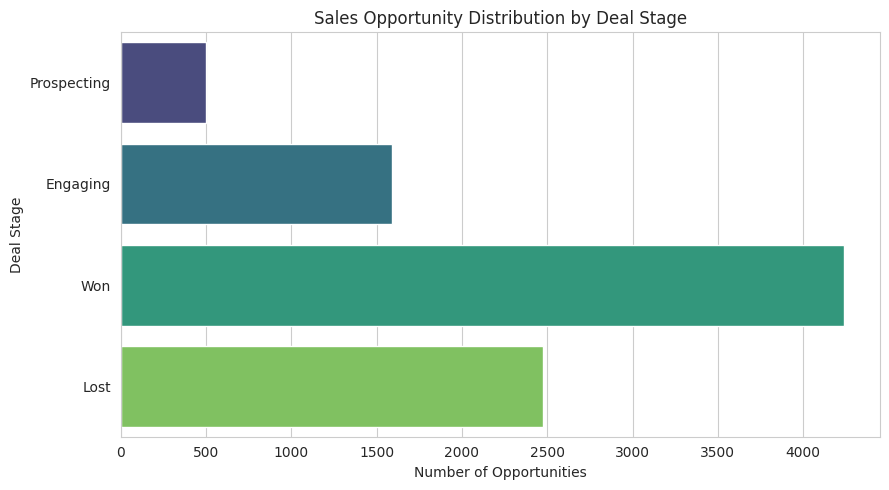

In [29]:
plt.figure(figsize=(9, 5))
sns.barplot(x=stage_counts.values, y=stage_counts.index, hue=stage_counts.index, palette="viridis", legend=False)
plt.title("Sales Opportunity Distribution by Deal Stage")
plt.xlabel("Number of Opportunities")
plt.ylabel("Deal Stage")
plt.tight_layout()
plt.show()

In [30]:
open_stage = eda.loc[eda["pipeline_status"] == "Open", "deal_stage"].value_counts()
open_stage_pct = (open_stage / open_stage.sum() * 100).round(2)
print("Open pipeline share of total:", round(eda["open_flag"].mean() * 100, 2), "%")
pd.DataFrame({"opportunities": open_stage, "pct_of_open": open_stage_pct})

Open pipeline share of total: 23.74 %


,opportunities,pct_of_open
deal_stage,,
Engaging,1589,76.07
Prospecting,500,23.93


In [31]:
revenue_by_status = (
    eda.groupby("pipeline_status")["close_value"].sum()
    .reindex(["Open", "Won", "Lost"]).fillna(0)
)
revenue_by_status

pipeline_status
Open           0.0
Won     10005534.0
Lost           0.0
Name: close_value, dtype: float64

In [32]:
cycle_by_outcome = (
    eda.loc[eda["deal_stage"].isin(["Won", "Lost"])]
    .groupby("deal_stage")["sales_cycle_days"]
    .agg(["count", "mean", "median"]).round(2)
)
cycle_by_outcome

,count,mean,median
deal_stage,,,
Lost,2473,41.48,14.0
Won,4238,51.78,57.0


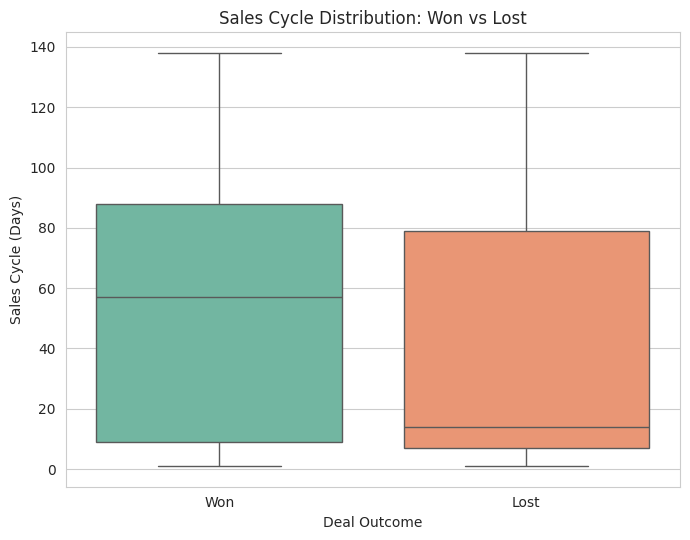

In [33]:
plt.figure(figsize=(7, 5.5))
sns.boxplot(data=eda.loc[eda["deal_stage"].isin(["Won", "Lost"])], x="deal_stage", y="sales_cycle_days",
            hue="deal_stage", palette="Set2", legend=False)
plt.title("Sales Cycle Distribution: Won vs Lost")
plt.xlabel("Deal Outcome")
plt.ylabel("Sales Cycle (Days)")
plt.tight_layout()
plt.show()

**Findings:** Won opportunities make up 48.2% of the pipeline and Lost 28.1%; the remaining 23.7% is still open, split roughly 3-to-1 between `Engaging` (76.1%) and `Prospecting` (23.9%) — most open pipeline has already had first contact rather than sitting untouched. All realized revenue ($10.01M) comes from Won deals by definition; Lost opportunities have `close_value = 0`, while Open opportunities have no realized `close_value` (missing/NaN), confirming the cleaning logic from Part 2 behaves as intended. Won deals take meaningfully longer to close (median 57 days) than Lost deals (median 14 days) — opportunities that are going to fail tend to fail fast, while conversions require sustained engagement. This pattern is explored further in Section 5.5.

## 5.2 — Product Performance

**Business question:** Which products drive the most opportunities, the best conversion, and the most revenue — and are these the same products?

In [34]:
product_performance = (
    eda.groupby("product")
    .agg(opportunities=("opportunity_id", "nunique"),
         won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"))
    .reset_index()
)
product_performance["closed_opportunities"] = product_performance["won_opportunities"] + product_performance["lost_opportunities"]
product_performance["win_rate_pct"] = (product_performance["won_opportunities"] / product_performance["closed_opportunities"] * 100).round(2)
product_performance.sort_values("opportunities", ascending=False)

,product,opportunities,won_opportunities,lost_opportunities,closed_opportunities,win_rate_pct
1,GTX Basic,1866,915,521,1436,63.72
6,MG Special,1651,793,430,1223,64.84
4,GTX Pro,1480,729,418,1147,63.56
5,MG Advanced,1412,654,430,1084,60.33
2,GTX Plus Basic,1383,653,398,1051,62.13
3,GTX Plus Pro,968,479,266,745,64.30
0,GTK 500,40,15,10,25,60.00


In [35]:
# Revenue and deal-size metrics computed on WON opportunities only
revenue_by_product = (
    eda[eda["deal_stage"] == "Won"]
    .groupby("product")["close_value"]
    .agg(won_revenue="sum", avg_won_deal="mean", median_won_deal="median", won_opportunities="count")
    .reset_index()
)

product_summary = (
    product_performance[["product", "opportunities", "closed_opportunities", "win_rate_pct"]]
    .merge(revenue_by_product, on="product", how="left")
    .merge(eda.groupby("product")["sales_price"].first().reset_index(), on="product", how="left")
    .sort_values("won_revenue", ascending=False)
)
product_summary.round(2)

,product,opportunities,closed_opportunities,win_rate_pct,won_revenue,avg_won_deal,median_won_deal,won_opportunities,sales_price
4,GTX Pro,1480,1147,63.56,3510578.0,4815.61,4828.0,729,4821
3,GTX Plus Pro,968,745,64.30,2629651.0,5489.88,5503.0,479,5482
5,MG Advanced,1412,1084,60.33,2216387.0,3388.97,3382.5,654,3393
2,GTX Plus Basic,1383,1051,62.13,705275.0,1080.05,1083.0,653,1096
1,GTX Basic,1866,1436,63.72,499263.0,545.64,547.0,915,550
0,GTK 500,40,25,60.00,400612.0,26707.47,25897.0,15,26768
6,MG Special,1651,1223,64.84,43768.0,55.19,55.0,793,55


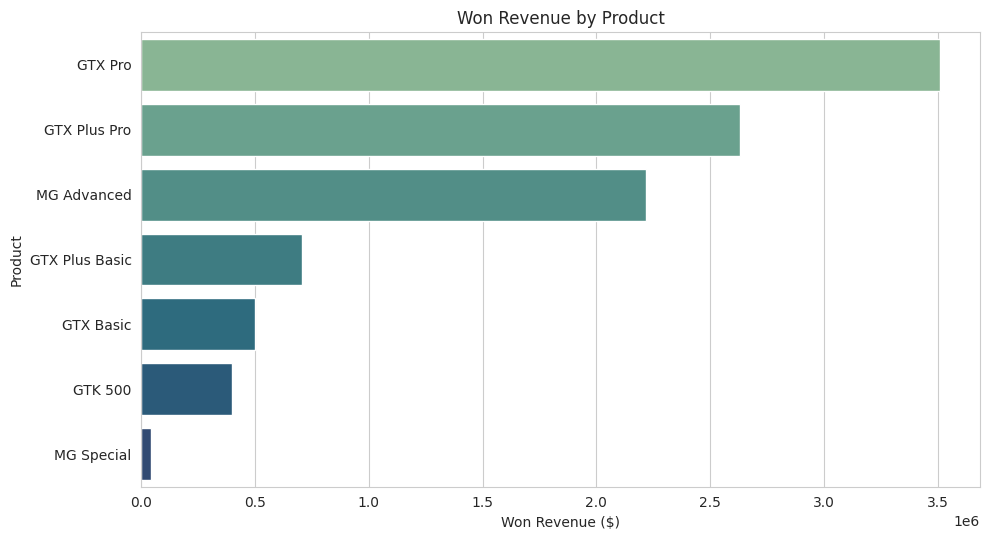

In [36]:
plt.figure(figsize=(10, 5.5))
sns.barplot(data=product_summary, x="won_revenue", y="product", hue="product", palette="crest", legend=False)
plt.title("Won Revenue by Product")
plt.xlabel("Won Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

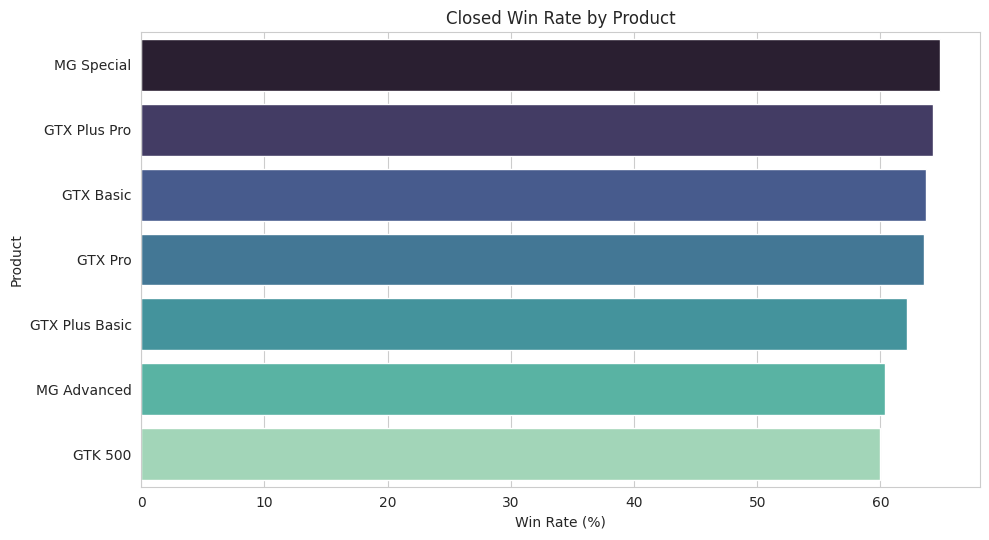

In [37]:
plt.figure(figsize=(10, 5.5))
sns.barplot(data=product_summary.sort_values("win_rate_pct", ascending=False), x="win_rate_pct", y="product",
            hue="product", palette="mako", legend=False)
plt.title("Closed Win Rate by Product")
plt.xlabel("Win Rate (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

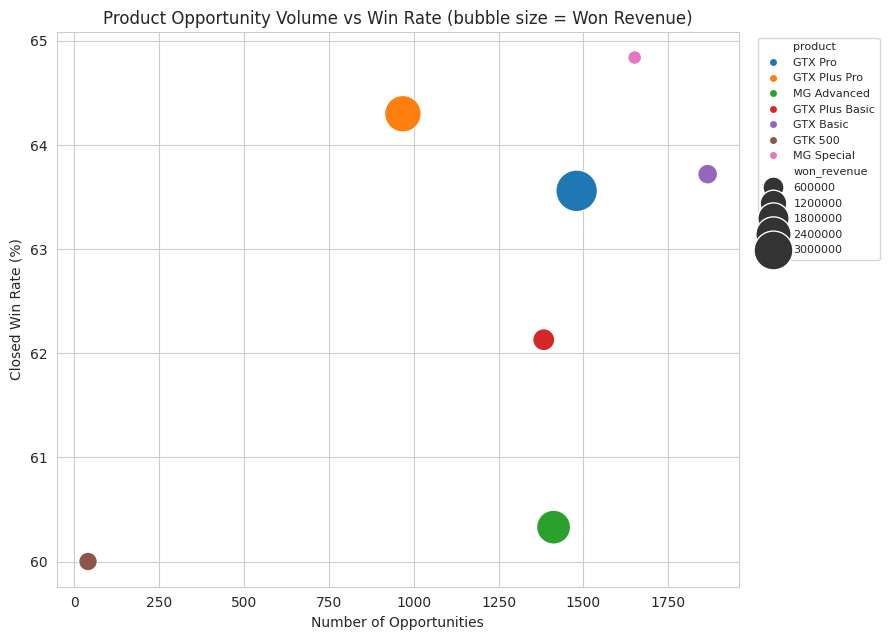

In [38]:
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=product_summary, x="opportunities", y="win_rate_pct", size="won_revenue",
                 hue="product", sizes=(100, 900))
plt.title("Product Opportunity Volume vs Win Rate (bubble size = Won Revenue)")
plt.xlabel("Number of Opportunities")
plt.ylabel("Closed Win Rate (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [39]:
series_performance = (
    eda.groupby("series")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"))
    .reset_index()
)
series_performance["closed_opportunities"] = series_performance["won_opportunities"] + series_performance["lost_opportunities"]
series_performance["win_rate_pct"] = (series_performance["won_opportunities"] / series_performance["closed_opportunities"] * 100).round(2)
series_performance.sort_values("won_revenue", ascending=False)

,series,opportunities,won_opportunities,lost_opportunities,won_revenue,closed_opportunities,win_rate_pct
1,GTX,5697,2776,1603,7344767.0,4379,63.39
2,MG,3063,1447,860,2260155.0,2307,62.72
0,GTK,40,15,10,400612.0,25,60.00


**Findings:**

- **GTX Pro** is the largest single contributor to won revenue (**$3.51M**) on strong volume (1,480 opportunities) and an above-average win rate (63.6%).
- **GTX Plus Pro** combines the **highest average won-deal value** ($5,490) with a strong win rate (64.3%) — the most efficient high-value product.
- **MG Special** has the **highest win rate of all products** (64.8%) but an average deal value of just $55, so despite winning most often it contributes minimal revenue ($43.8K) — high conversion does not imply high revenue.
- **GTX Basic** generates the **highest opportunity volume** (1,866) but the lowest revenue per deal among the high-volume products ($546 average) — a volume play, not a value play.
- **MG Advanced** has the **lowest win rate** among the major products (60.3%) yet still contributes $2.2M in revenue purely on volume (1,412 opportunities).
- **GTK 500** shows an exceptionally high average deal value (~$26,700) but only 15 Won opportunities — directionally interesting but too small a sample to generalize confidently.

No single metric (volume, win rate, or revenue) identifies the "best" product on its own — the three must be read together, which is exactly why `product_summary` reports them side by side.

## 5.3 — Sales Team & Regional Performance

**Business question:** Which agents, managers, and regional offices perform best — and is that performance driven by volume, conversion efficiency, or deal size?

**Methodology note:** average/median deal size below is computed **only on Won opportunities** (`eda[eda["deal_stage"]=="Won"]`), joined back onto the volume/win-rate table. Computing it over all closed opportunities would silently include Lost deals recorded at `close_value = 0` and understate true deal size — this is deliberately avoided throughout this section.

### Sales Agents

In [40]:
agent_base = (
    eda.groupby("sales_agent")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"),
         avg_sales_cycle=("sales_cycle_days", "mean"))
    .reset_index()
)
agent_base["closed_opportunities"] = agent_base["won_opportunities"] + agent_base["lost_opportunities"]
agent_base["win_rate_pct"] = (agent_base["won_opportunities"] / agent_base["closed_opportunities"] * 100)

won_agent_deals = (
    eda[eda["deal_stage"] == "Won"].groupby("sales_agent")["close_value"]
    .agg(avg_won_deal="mean", median_won_deal="median").reset_index()
)

agent_performance = (
    agent_base.merge(won_agent_deals, on="sales_agent", how="left")
    [["sales_agent", "opportunities", "closed_opportunities", "won_opportunities", "lost_opportunities",
      "win_rate_pct", "won_revenue", "avg_won_deal", "median_won_deal", "avg_sales_cycle"]]
    .sort_values("won_revenue", ascending=False)
)
agent_performance.round(2).head(10)

,sales_agent,opportunities,closed_opportunities,won_opportunities,lost_opportunities,win_rate_pct,won_revenue,avg_won_deal,median_won_deal,avg_sales_cycle
6,Darcel Schlecht,747,553,349,204,63.11,1153214.0,3304.34,4247.0,45.84
26,Vicki Laflamme,451,347,221,126,63.69,478396.0,2164.69,1027.0,46.56
15,Kary Hendrixson,438,335,209,126,62.39,454298.0,2173.67,948.0,49.85
2,Cassey Cress,346,261,163,98,62.45,450489.0,2763.74,3280.0,45.96
7,Donn Cantrell,275,275,158,117,57.45,445860.0,2821.90,3227.5,48.93
22,Reed Clapper,237,237,155,82,65.40,438336.0,2827.97,3252.0,44.57
29,Zane Levy,349,261,161,100,61.69,430068.0,2671.23,1195.0,44.41
4,Corliss Cosme,310,229,150,79,65.50,421036.0,2806.91,2917.5,47.22
12,James Ascencio,267,206,135,71,65.53,413533.0,3063.21,3624.0,50.49
5,Daniell Hammack,259,187,114,73,60.96,364229.0,3194.99,3769.5,44.86


In [41]:
# Highest win rate among agents with a meaningful sample size (>= 50 closed opportunities)
(
    agent_performance[agent_performance["closed_opportunities"] >= 50]
    .sort_values("win_rate_pct", ascending=False)
    [["sales_agent", "closed_opportunities", "win_rate_pct", "won_revenue"]]
    .round(2).head(10)
)

,sales_agent,closed_opportunities,win_rate_pct,won_revenue
11,Hayden Neloms,152,70.39,272111.0
19,Maureen Marcano,213,69.95,350395.0
28,Wilburn Farren,79,69.62,157640.0
3,Cecily Lampkin,160,66.88,229800.0
25,Versie Hillebrand,264,66.67,187693.0
20,Moses Frase,195,66.15,207182.0
1,Boris Faz,153,66.01,261631.0
12,James Ascencio,206,65.53,413533.0
4,Corliss Cosme,229,65.50,421036.0
23,Rosalina Dieter,110,65.45,235403.0


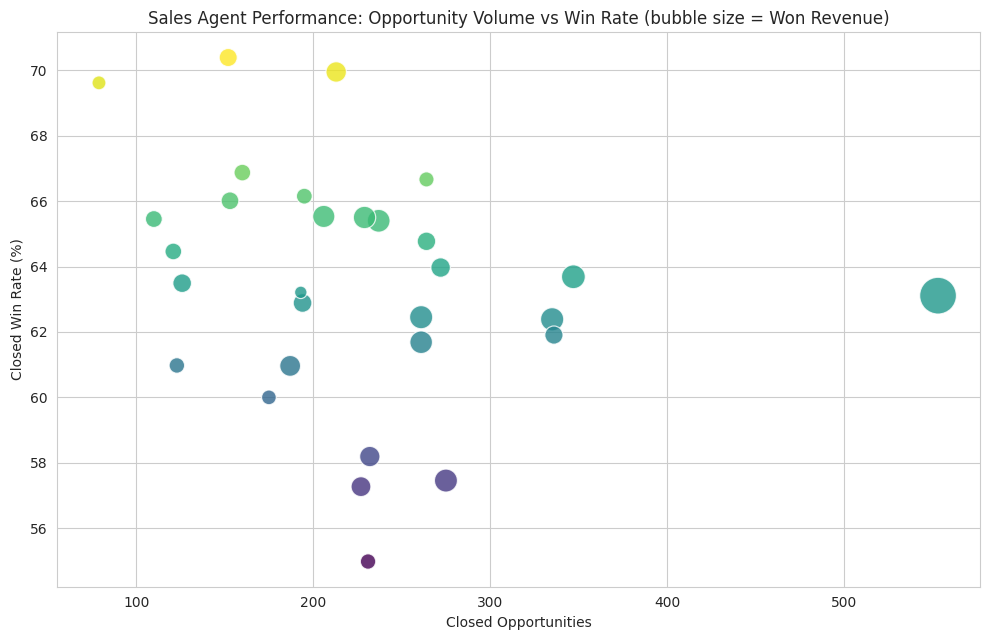

In [42]:
plt.figure(figsize=(10, 6.5))
sns.scatterplot(data=agent_performance, x="closed_opportunities", y="win_rate_pct",
                 size="won_revenue", hue="win_rate_pct", palette="viridis", sizes=(80, 700), alpha=0.8, legend=False)
plt.title("Sales Agent Performance: Opportunity Volume vs Win Rate (bubble size = Won Revenue)")
plt.xlabel("Closed Opportunities")
plt.ylabel("Closed Win Rate (%)")
plt.tight_layout()
plt.show()

*How to read this chart:* agents in the upper-right (high volume, high win rate) are elite performers; upper-left (low volume, high win rate) are efficient but under-utilized; lower-right (high volume, low win rate) represent the largest opportunity for coaching, since small conversion gains there move the most revenue; lower-left is the lowest priority.

### Sales Managers

In [43]:
manager_base = (
    eda.groupby("manager")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"),
         avg_sales_cycle=("sales_cycle_days", "mean"))
    .reset_index()
)
manager_base["closed_opportunities"] = manager_base["won_opportunities"] + manager_base["lost_opportunities"]
manager_base["win_rate_pct"] = manager_base["won_opportunities"] / manager_base["closed_opportunities"] * 100

won_manager_deals = (
    eda[eda["deal_stage"] == "Won"].groupby("manager")["close_value"]
    .agg(avg_won_deal="mean", median_won_deal="median").reset_index()
)

manager_performance = (
    manager_base.merge(won_manager_deals, on="manager", how="left")
    .sort_values("won_revenue", ascending=False)
)
manager_performance.round(2)

,manager,opportunities,won_opportunities,lost_opportunities,won_revenue,avg_sales_cycle,closed_opportunities,win_rate_pct,avg_won_deal,median_won_deal
3,Melvin Marxen,1929,882,536,2251930.0,47.82,1418,62.20,2553.21,1214.5
5,Summer Sewald,1701,828,459,1964750.0,48.47,1287,64.34,2372.89,1089.0
4,Rocco Neubert,1327,691,422,1960545.0,45.84,1113,62.08,2837.26,3249.0
1,Celia Rouche,1296,610,352,1603897.0,47.45,962,63.41,2629.34,1107.0
0,Cara Losch,964,480,265,1130049.0,49.04,745,64.43,2354.27,1140.5
2,Dustin Brinkmann,1583,747,439,1094363.0,49.44,1186,62.98,1465.01,544.0


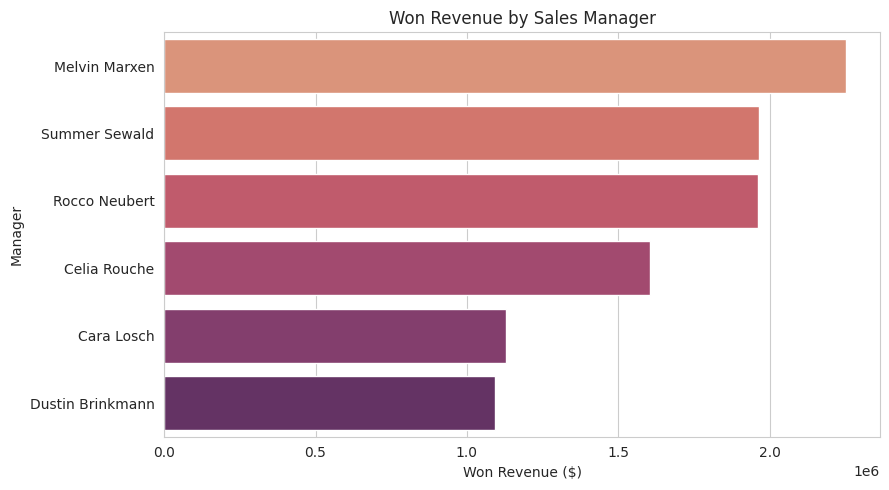

In [44]:
plt.figure(figsize=(9, 5))
sns.barplot(data=manager_performance, x="won_revenue", y="manager", hue="manager", palette="flare", legend=False)
plt.title("Won Revenue by Sales Manager")
plt.xlabel("Won Revenue ($)")
plt.ylabel("Manager")
plt.tight_layout()
plt.show()

### Regional Offices

In [45]:
regional_base = (
    eda.groupby("regional_office")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"),
         avg_sales_cycle=("sales_cycle_days", "mean"))
    .reset_index()
)
regional_base["closed_opportunities"] = regional_base["won_opportunities"] + regional_base["lost_opportunities"]
regional_base["win_rate_pct"] = regional_base["won_opportunities"] / regional_base["closed_opportunities"] * 100

won_regional_deals = (
    eda[eda["deal_stage"] == "Won"].groupby("regional_office")["close_value"]
    .agg(avg_won_deal="mean", median_won_deal="median").reset_index()
)

regional_performance = (
    regional_base.merge(won_regional_deals, on="regional_office", how="left")
    .sort_values("won_revenue", ascending=False)
)
regional_performance.round(2)

,regional_office,opportunities,won_opportunities,lost_opportunities,won_revenue,avg_sales_cycle,closed_opportunities,win_rate_pct,avg_won_deal,median_won_deal
2,West,2997,1438,811,3568647.0,48.03,2249,63.94,2481.67,1096.5
0,Central,3512,1629,975,3346293.0,48.56,2604,62.56,2054.20,1047.0
1,East,2291,1171,687,3090594.0,47.12,1858,63.02,2639.28,2984.0


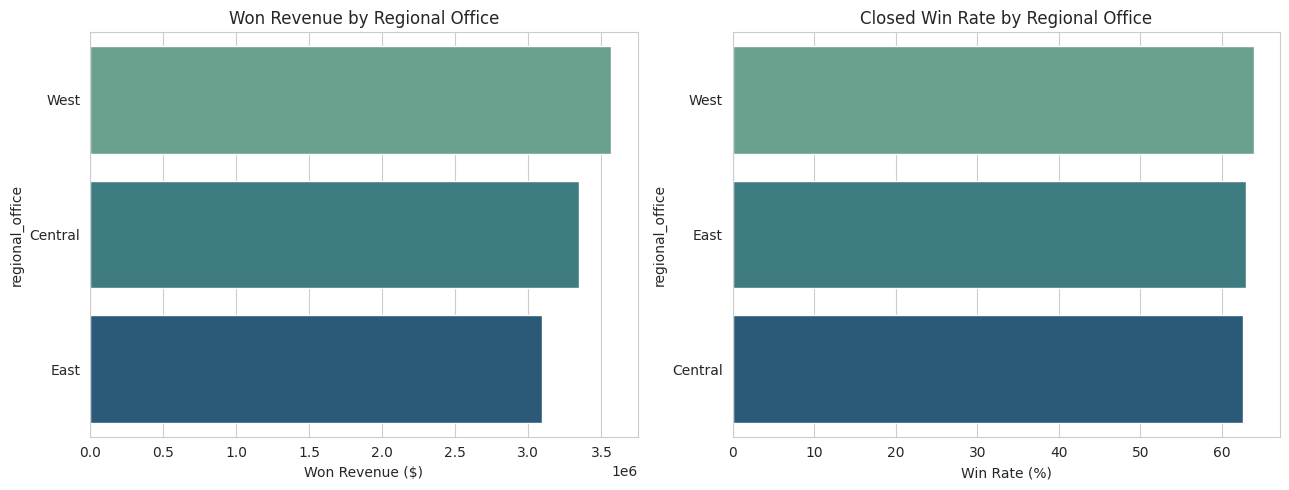

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=regional_performance, x="won_revenue", y="regional_office", hue="regional_office",
            palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Won Revenue by Regional Office")
axes[0].set_xlabel("Won Revenue ($)")

sns.barplot(data=regional_performance.sort_values("win_rate_pct", ascending=False), x="win_rate_pct", y="regional_office",
            hue="regional_office", palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Closed Win Rate by Regional Office")
axes[1].set_xlabel("Win Rate (%)")

plt.tight_layout()
plt.show()

In [47]:
# Region + manager cross-tab, and a simple volume/win-rate performance-profile classification for agents
manager_region = (
    eda.groupby(["regional_office", "manager"])
    .agg(opportunities=("opportunity_id", "nunique"), won_revenue=("close_value", "sum"),
         won_opportunities=("won_flag", "sum"), lost_opportunities=("lost_flag", "sum"))
    .reset_index()
)
manager_region["win_rate_pct"] = manager_region["won_opportunities"] / (manager_region["won_opportunities"] + manager_region["lost_opportunities"]) * 100
manager_region.sort_values("won_revenue", ascending=False).round(2)

,regional_office,manager,opportunities,won_revenue,won_opportunities,lost_opportunities,win_rate_pct
1,Central,Melvin Marxen,1929,2251930.0,882,536,62.20
5,West,Summer Sewald,1701,1964750.0,828,459,64.34
3,East,Rocco Neubert,1327,1960545.0,691,422,62.08
4,West,Celia Rouche,1296,1603897.0,610,352,63.41
2,East,Cara Losch,964,1130049.0,480,265,64.43
0,Central,Dustin Brinkmann,1583,1094363.0,747,439,62.98


In [48]:
volume_median = agent_performance["closed_opportunities"].median()
win_rate_median = agent_performance["win_rate_pct"].median()

agent_performance["performance_profile"] = np.select(
    [
        (agent_performance["closed_opportunities"] >= volume_median) & (agent_performance["win_rate_pct"] >= win_rate_median),
        (agent_performance["closed_opportunities"] >= volume_median) & (agent_performance["win_rate_pct"] < win_rate_median),
        (agent_performance["closed_opportunities"] < volume_median) & (agent_performance["win_rate_pct"] >= win_rate_median),
    ],
    ["High Volume / High Win Rate", "High Volume / Low Win Rate", "Low Volume / High Win Rate"],
    default="Low Volume / Low Win Rate"
)
agent_performance["performance_profile"].value_counts()

performance_profile
High Volume / Low Win Rate     9
Low Volume / High Win Rate     9
High Volume / High Win Rate    6
Low Volume / Low Win Rate      6
Name: count, dtype: int64

**Findings:**

- **Sales Agents:** Darcel Schlecht is the largest individual revenue contributor ($1.15M from 349 Won opportunities, 63.1% win rate), driven primarily by high opportunity volume (747 total, largest in the team) and a large average won deal ($3,304), not by an outlier win rate — several agents (e.g. Hayden Neloms, 70.4%) convert at a notably higher rate on lower volume. Revenue leadership and conversion efficiency are distinct skills.
- **Managers:** Melvin Marxen's team leads on both volume (1,929 opportunities) and won revenue ($2.25M), but not on win rate — Cara Losch's team converts at 64.4% and Summer Sewald's at 64.3%, both above Melvin's 62.2%. Manager performance should be evaluated on scale and efficiency together, not revenue alone.
- **Regions:** West leads on both won revenue ($3.57M) and win rate (63.9%). Central handles the largest opportunity volume (3,512) but has the lowest win rate (62.6%), making its conversion pattern worth further investigation. East has the smallest volume (2,291) but the highest average won deal ($2,639), suggesting its revenue mix is more influenced by deal value than by volume or conversion.

## 5.4 — Account & Sector Analysis

**Business question:** How concentrated is revenue among customer accounts, and does customer sector or size relate to performance? (Restricted to the 7,375 opportunities with a matched account — see Part 3.)

In [49]:
account_base = (
    eda[eda["account"].notna()]
    .groupby("account")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"),
         avg_sales_cycle=("sales_cycle_days", "mean"), sector=("sector", "first"),
         account_revenue=("account_revenue", "first"), employees=("employees", "first"),
         office_location=("office_location", "first"))
    .reset_index()
)
account_base["closed_opportunities"] = account_base["won_opportunities"] + account_base["lost_opportunities"]
account_base["win_rate_pct"] = account_base["won_opportunities"] / account_base["closed_opportunities"] * 100

won_account_deals = (
    eda[eda["deal_stage"] == "Won"].groupby("account")["close_value"]
    .agg(avg_won_deal="mean", median_won_deal="median").reset_index()
)

account_performance = account_base.merge(won_account_deals, on="account", how="left")
account_performance.sort_values("won_revenue", ascending=False).round(2).head(10)

,account,opportunities,won_opportunities,lost_opportunities,won_revenue,avg_sales_cycle,sector,account_revenue,employees,office_location,closed_opportunities,win_rate_pct,avg_won_deal,median_won_deal
40,Kan-code,196,115,72,341455.0,47.11,software,11698.03,34288.0,United States,187,61.50,2969.17,3290.0
42,Konex,178,108,63,269245.0,43.54,technology,7708.38,13756.0,United States,171,63.16,2493.01,1273.5
11,Condax,170,105,54,206410.0,48.68,medical,4.54,9.0,United States,159,66.04,1965.81,932.0
9,Cheers,98,57,33,198020.0,46.87,entertainment,4269.90,6472.0,United States,90,63.33,3474.04,1130.0
34,Hottechi,200,111,82,194957.0,48.12,technology,8170.38,16499.0,Korea,193,57.51,1756.37,655.0
30,Goodsilron,95,65,23,182522.0,40.16,marketing,2952.73,5107.0,United States,88,73.86,2808.03,1096.0
71,Treequote,116,65,41,176751.0,49.19,telecommunications,5266.09,8595.0,United States,106,61.32,2719.25,3165.0
74,Warephase,106,70,31,170046.0,52.06,services,2041.73,5276.0,United States,101,69.31,2429.23,1192.0
75,Xx-holding,87,48,31,169357.0,43.77,finance,7537.24,20293.0,United States,79,60.76,3528.27,2889.0
37,Isdom,119,65,47,164683.0,40.89,medical,3178.24,4540.0,United States,112,58.04,2533.58,2837.0


In [50]:
# Top accounts by win rate, minimum 20 closed opportunities for a meaningful rate
(
    account_performance[account_performance["closed_opportunities"] >= 20]
    .sort_values("win_rate_pct", ascending=False)
    [["account", "sector", "closed_opportunities", "win_rate_pct", "won_revenue"]]
    .round(2).head(10)
)

,account,sector,closed_opportunities,win_rate_pct,won_revenue
55,Rangreen,technology,100,75.00,151777.0
30,Goodsilron,marketing,88,73.86,182522.0
49,Newex,services,51,72.55,82622.0
53,Plusstrip,entertainment,46,71.74,89208.0
81,Zoomit,entertainment,46,71.74,76684.0
16,Donquadtech,technology,77,71.43,147976.0
25,Gekko & Co,retail,85,70.59,134731.0
13,Dalttechnology,software,61,70.49,77936.0
22,Finjob,employment,81,70.37,127569.0
28,Gogozoom,telecommunications,73,69.86,85047.0


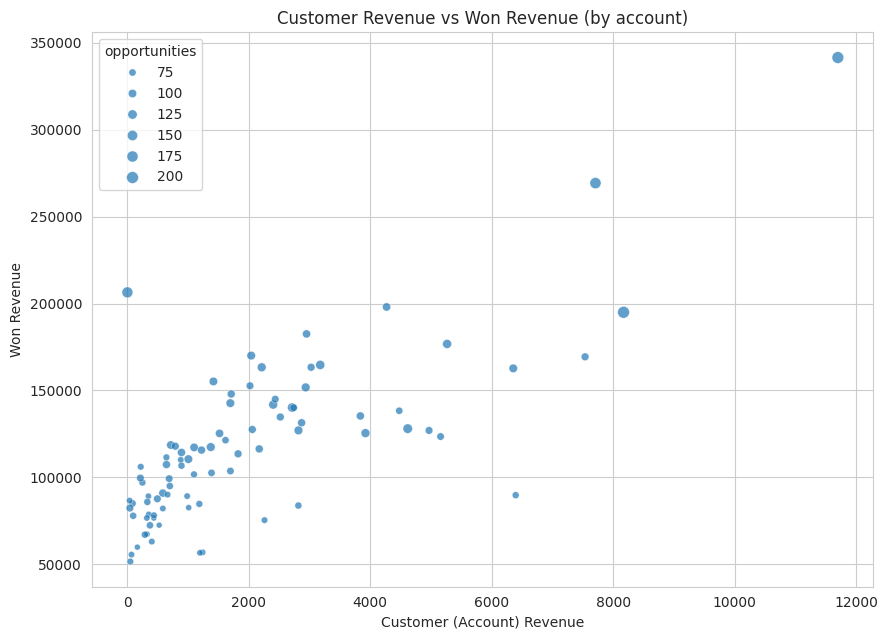

In [51]:
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=account_performance, x="account_revenue", y="won_revenue", size="opportunities", alpha=0.7)
plt.title("Customer Revenue vs Won Revenue (by account)")
plt.xlabel("Customer (Account) Revenue")
plt.ylabel("Won Revenue")
plt.tight_layout()
plt.show()

### Customer Concentration

In [52]:
total_account_revenue = account_performance["won_revenue"].sum()
top10_share = account_performance.nlargest(10, "won_revenue")["won_revenue"].sum() / total_account_revenue * 100
top5_share = account_performance.nlargest(5, "won_revenue")["won_revenue"].sum() / total_account_revenue * 100

print(f"Top 10 accounts share of account-attributed won revenue: {top10_share:.2f}%")
print(f"Top 5 accounts share of account-attributed won revenue:  {top5_share:.2f}%")

Top 10 accounts share of account-attributed won revenue: 20.72%
Top 5 accounts share of account-attributed won revenue:  12.09%


In [53]:
account_performance["won_revenue_quartile"] = pd.qcut(
    account_performance["won_revenue"], q=4,
    labels=["Low Value", "Mid-Low Value", "Mid-High Value", "High Value"]
)

account_segment_summary = (
    account_performance.groupby("won_revenue_quartile", observed=True)
    .agg(accounts=("account", "count"), opportunities=("opportunities", "sum"),
         won_revenue=("won_revenue", "sum"), avg_win_rate=("win_rate_pct", "mean"),
         avg_deal=("avg_won_deal", "mean"))
    .reset_index()
)
account_segment_summary.round(2)

,won_revenue_quartile,accounts,opportunities,won_revenue,avg_win_rate,avg_deal
0,Low Value,22,1386,1587572.0,62.58,2134.76
1,Mid-Low Value,21,1539,2061114.0,63.37,2440.43
2,Mid-High Value,21,1971,2616622.0,61.75,2391.58
3,High Value,21,2479,3740226.0,65.14,2591.35


### Sector Analysis

In [54]:
sector_base = (
    eda[eda["sector"].notna()]
    .groupby("sector")
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"),
         avg_sales_cycle=("sales_cycle_days", "mean"), accounts=("account", "nunique"))
    .reset_index()
)
sector_base["closed_opportunities"] = sector_base["won_opportunities"] + sector_base["lost_opportunities"]
sector_base["win_rate_pct"] = sector_base["won_opportunities"] / sector_base["closed_opportunities"] * 100

won_sector_deals = (
    eda[eda["deal_stage"] == "Won"].groupby("sector")["close_value"]
    .agg(avg_won_deal="mean", median_won_deal="median").reset_index()
)

sector_performance = sector_base.merge(won_sector_deals, on="sector", how="left").sort_values("won_revenue", ascending=False)
sector_performance.round(2)

,sector,opportunities,won_opportunities,lost_opportunities,won_revenue,avg_sales_cycle,accounts,closed_opportunities,win_rate_pct,avg_won_deal,median_won_deal
5,retail,1397,799,468,1867528.0,48.88,17,1267,63.06,2337.33,1122.0
8,technology,1165,671,387,1515487.0,47.19,12,1058,63.42,2258.55,1104.0
4,medical,1051,592,358,1359595.0,46.45,12,950,62.32,2296.61,1101.5
7,software,757,450,254,1077934.0,49.74,7,704,63.92,2395.41,1171.0
2,finance,678,375,238,950908.0,47.89,8,613,61.17,2535.75,1170.0
3,marketing,674,404,219,922321.0,46.25,8,623,64.85,2282.97,1079.0
1,entertainment,451,260,142,689007.0,49.51,6,402,64.68,2650.03,1136.0
9,telecommunications,501,285,171,653574.0,49.03,6,456,62.50,2293.24,1100.0
6,services,390,223,129,533006.0,47.57,5,352,63.35,2390.16,1105.0
0,employment,311,179,107,436174.0,48.44,4,286,62.59,2436.73,1113.0


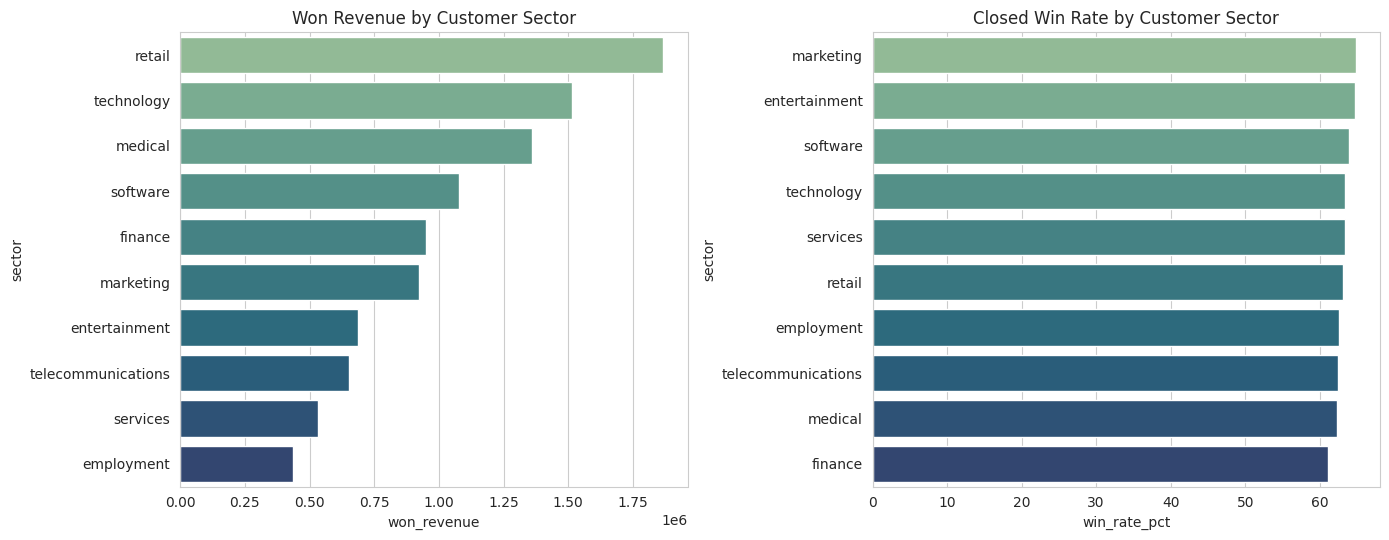

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(data=sector_performance, x="won_revenue", y="sector", hue="sector", palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Won Revenue by Customer Sector")

sns.barplot(data=sector_performance.sort_values("win_rate_pct", ascending=False), x="win_rate_pct", y="sector",
            hue="sector", palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Closed Win Rate by Customer Sector")

plt.tight_layout()
plt.show()

**Findings:**

- **Concentration:** the top 10 accounts contribute **20.72%** of account-attributed won revenue (top 5: **12.09%**). This describes the share contributed by the largest account-level Won Revenue contributors in this dataset, without applying an external concentration benchmark.
- **Value segmentation:** accounts in the highest **Won-Revenue quartile** show the **highest average win rate** (65.1%) and the **highest average won-deal size** ($2,591) among the four segments. This quartile is based on each account's own `won_revenue`, not customer `account_revenue`.
- **Sector:** **Retail** is the top sector by won revenue ($1.87M) and by opportunity volume; win rates across sectors are fairly narrow (roughly 61–65%), meaning sector differences in revenue are driven mainly by volume and account mix rather than by large swings in conversion efficiency.

## 5.5 — Time & Sales-Cycle Analysis

**Business question:** How has performance trended over the observed window, and how does sales-cycle length relate to conversion?

**Caveat carried from Part 1:** engagement starts October 2016, so Q1 2017 is the *close* quarter for opportunities that had the least time in the pipeline. Q1 2017 figures below should not be compared directly with the fuller Q2–Q4 2017 quarters.

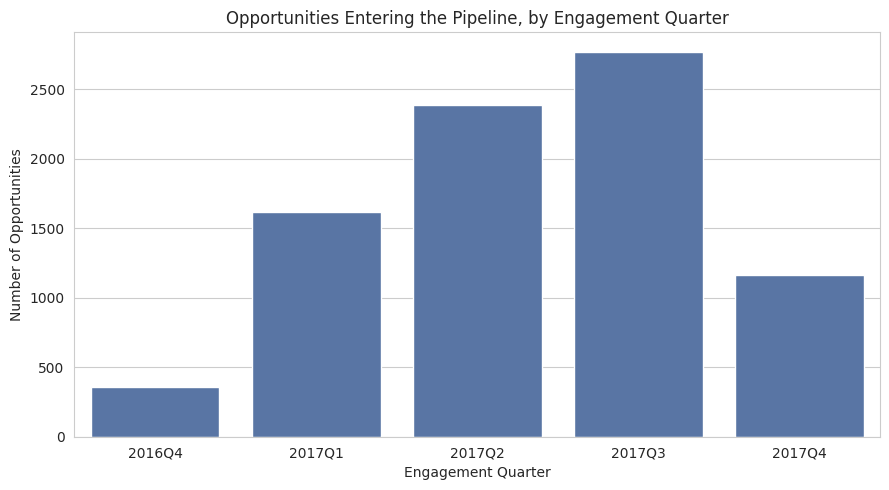

In [56]:
opps_by_engage_q = eda.groupby("engage_quarter")["opportunity_id"].nunique().sort_index()
plt.figure(figsize=(9, 5))
sns.barplot(x=opps_by_engage_q.index, y=opps_by_engage_q.values, color="#4C72B0")
plt.title("Opportunities Entering the Pipeline, by Engagement Quarter")
plt.xlabel("Engagement Quarter")
plt.ylabel("Number of Opportunities")
plt.tight_layout()
plt.show()

In [57]:
quarterly = (
    eda[eda["deal_stage"].isin(["Won", "Lost"])]
    .groupby("close_quarter")
    .agg(won_opportunities=("won_flag", "sum"), lost_opportunities=("lost_flag", "sum"),
         won_revenue=("close_value", "sum"))
    .reset_index()
)
quarterly["closed_opportunities"] = quarterly["won_opportunities"] + quarterly["lost_opportunities"]
quarterly["win_rate_pct"] = (quarterly["won_opportunities"] / quarterly["closed_opportunities"] * 100).round(2)
quarterly = quarterly.sort_values("close_quarter")
quarterly

,close_quarter,won_opportunities,lost_opportunities,won_revenue,closed_opportunities,win_rate_pct
0,2017Q1,531,116,1134672.0,647,82.07
1,2017Q2,1254,778,3086111.0,2032,61.71
2,2017Q3,1257,790,2982255.0,2047,61.41
3,2017Q4,1196,789,2802496.0,1985,60.25


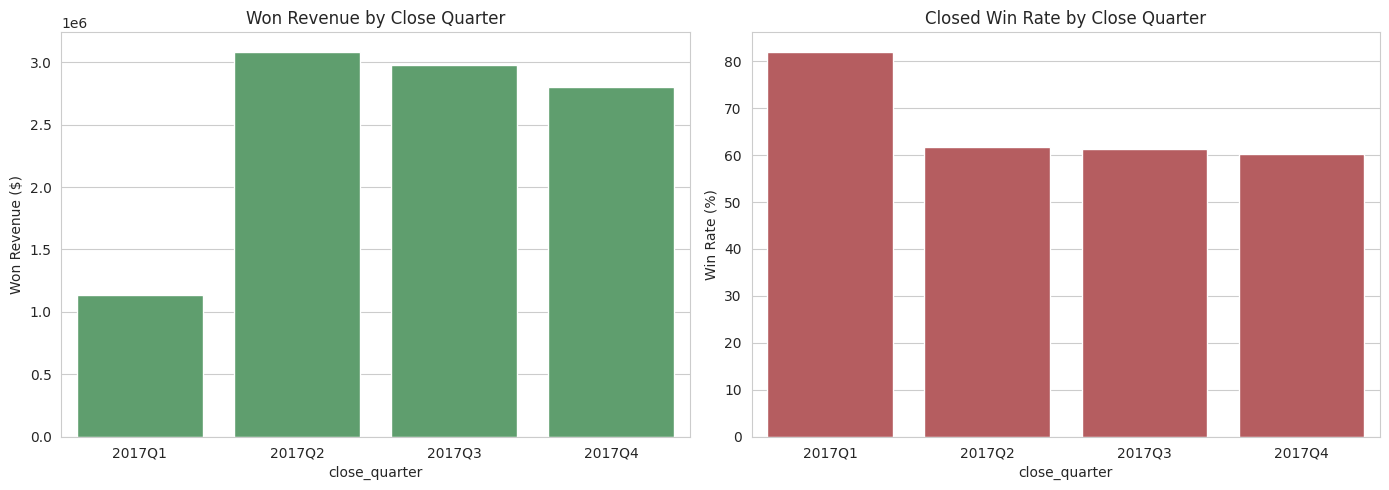

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=quarterly, x="close_quarter", y="won_revenue", color="#55A868", ax=axes[0])
axes[0].set_title("Won Revenue by Close Quarter")
axes[0].set_ylabel("Won Revenue ($)")

sns.barplot(data=quarterly, x="close_quarter", y="win_rate_pct", color="#C44E52", ax=axes[1])
axes[1].set_title("Closed Win Rate by Close Quarter")
axes[1].set_ylabel("Win Rate (%)")

plt.tight_layout()
plt.show()

In [59]:
closed_eda = eda[eda["deal_stage"].isin(["Won", "Lost"])].copy()
closed_eda["sales_cycle_group"] = pd.cut(
    closed_eda["sales_cycle_days"],
    bins=[0, 14, 30, 60, 90, np.inf],
    labels=["1-14 days", "15-30 days", "31-60 days", "61-90 days", "91+ days"]
)

cycle_group_summary = (
    closed_eda.groupby("sales_cycle_group", observed=True)
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"))
    .reset_index()
)
cycle_group_summary["win_rate_pct"] = (cycle_group_summary["won_opportunities"] / cycle_group_summary["opportunities"] * 100).round(2)
cycle_group_summary

,sales_cycle_group,opportunities,won_opportunities,lost_opportunities,win_rate_pct
0,1-14 days,2806,1557,1249,55.49
1,15-30 days,357,260,97,72.83
2,31-60 days,569,377,192,66.26
3,61-90 days,1621,1078,543,66.50
4,91+ days,1358,966,392,71.13


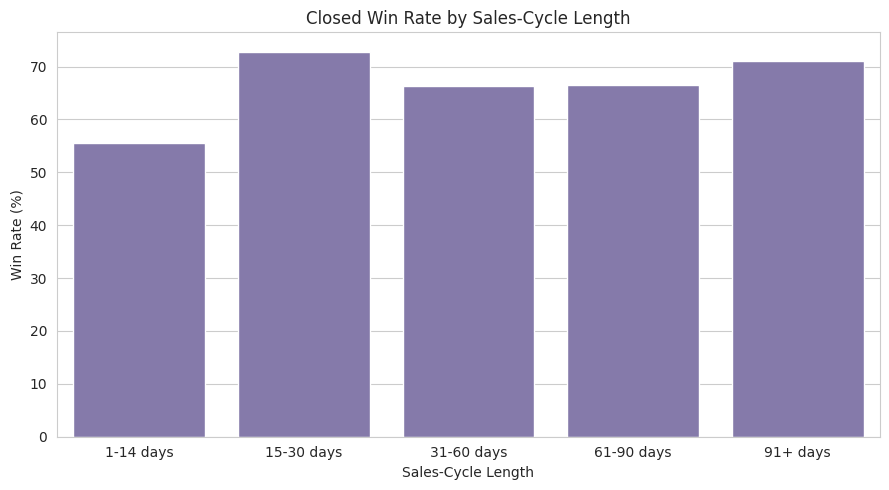

In [60]:
plt.figure(figsize=(9, 5))
sns.barplot(data=cycle_group_summary, x="sales_cycle_group", y="win_rate_pct", color="#8172B2")
plt.title("Closed Win Rate by Sales-Cycle Length")
plt.xlabel("Sales-Cycle Length")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.show()

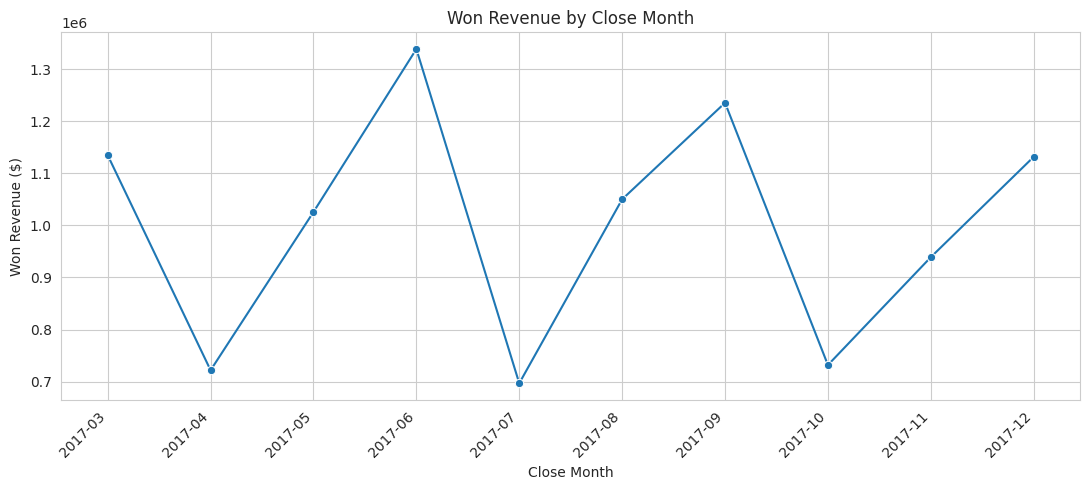

In [61]:
monthly = (
    eda[eda["deal_stage"] == "Won"]
    .assign(close_month_period=lambda d: d["close_date"].dt.to_period("M").astype(str))
    .groupby("close_month_period")["close_value"].sum()
    .reset_index(name="won_revenue")
)
plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly, x="close_month_period", y="won_revenue", marker="o")
plt.title("Won Revenue by Close Month")
plt.xlabel("Close Month")
plt.ylabel("Won Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Findings:**

- Won revenue and win rate both rise sharply from Q1 to Q2 2017 and then hold in a fairly narrow band through Q4 — consistent with Q1 being a partial, ramp-up quarter rather than a genuine performance dip (see caveat above).
- Sales-cycle length and win rate are **not linearly related**: the shortest cycles (1–14 days) have the *lowest* win rate, while 15–30 day and 91+ day cycles both show the highest win rates. The pattern is descriptive and does not establish that a longer cycle causes a higher chance of winning.
- **This is a descriptive association, not a causal claim.** We cannot conclude from this data alone that *extending* a deal's cycle would improve its odds of winning; cycle length and win rate may both be driven by an unobserved factor such as deal complexity or account fit.

## 5.6 — Cross-Factor Analysis & Final EDA Synthesis

**Business question:** Do the drivers identified above (product, region, sector, cycle length, account size) interact, or do they operate independently?

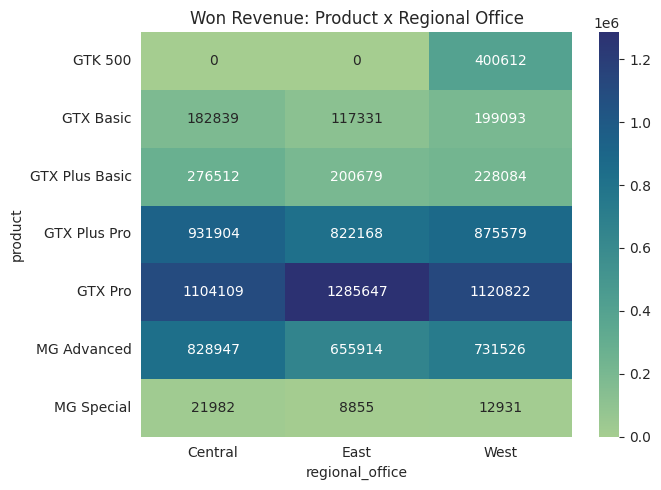

In [62]:
product_region = (
    eda.groupby(["product", "regional_office"])
    .agg(opportunities=("opportunity_id", "nunique"), won_opportunities=("won_flag", "sum"),
         lost_opportunities=("lost_flag", "sum"), won_revenue=("close_value", "sum"))
    .reset_index()
)
product_region["closed_opportunities"] = product_region["won_opportunities"] + product_region["lost_opportunities"]
product_region["win_rate_pct"] = (product_region["won_opportunities"] / product_region["closed_opportunities"] * 100).round(2)

revenue_pivot = product_region.pivot(index="product", columns="regional_office", values="won_revenue")
plt.figure(figsize=(7, 5))
sns.heatmap(revenue_pivot, annot=True, fmt=".0f", cmap="crest")
plt.title("Won Revenue: Product x Regional Office")
plt.tight_layout()
plt.show()

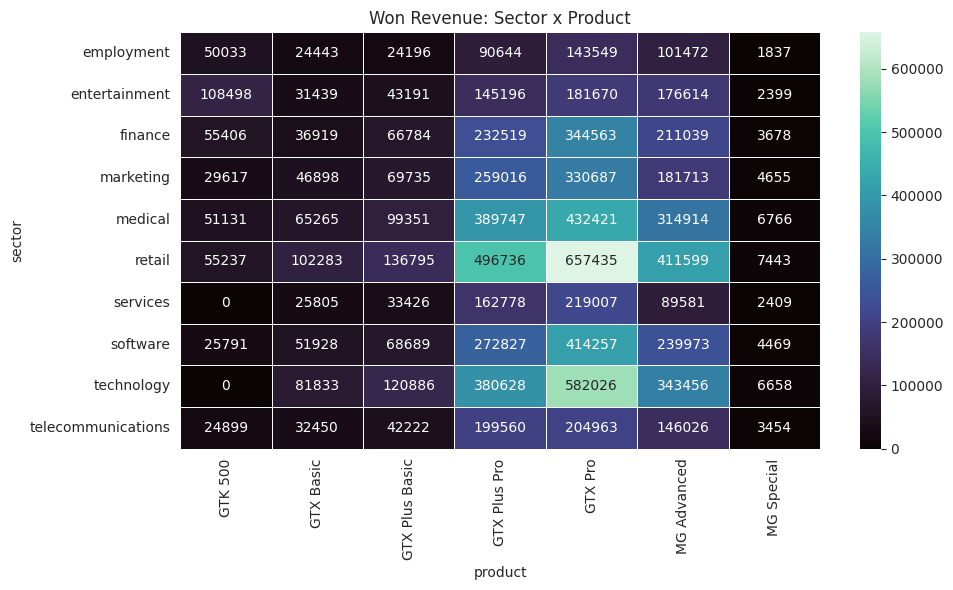

In [63]:
sector_product = (
    eda[eda["sector"].notna()]
    .groupby(["sector", "product"])
    .agg(won_revenue=("close_value", "sum"))
    .reset_index()
)
sector_pivot = sector_product.pivot(index="sector", columns="product", values="won_revenue").fillna(0)
plt.figure(figsize=(10, 6))
sns.heatmap(sector_pivot, annot=True, fmt=".0f", cmap="mako", linewidths=0.5)
plt.title("Won Revenue: Sector x Product")
plt.tight_layout()
plt.show()

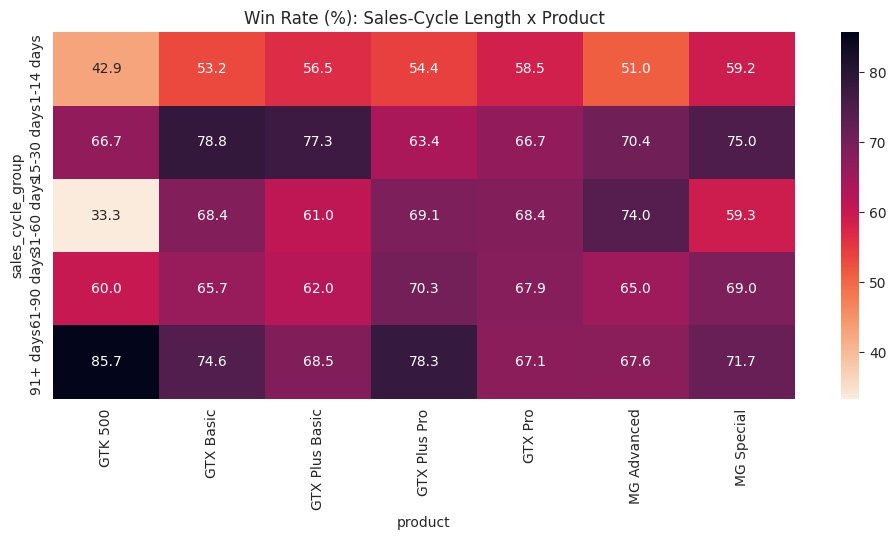

In [64]:
cycle_product = (
    closed_eda.groupby(["sales_cycle_group", "product"], observed=True)
    .agg(won_opportunities=("won_flag", "sum"), opportunities=("opportunity_id", "nunique"))
    .reset_index()
)
cycle_product["win_rate_pct"] = (cycle_product["won_opportunities"] / cycle_product["opportunities"] * 100).round(2)
cycle_product_pivot = cycle_product.pivot(index="sales_cycle_group", columns="product", values="win_rate_pct")

plt.figure(figsize=(10, 5.5))
sns.heatmap(cycle_product_pivot, annot=True, fmt=".1f", cmap="rocket_r")
plt.title("Win Rate (%): Sales-Cycle Length x Product")
plt.tight_layout()
plt.show()

Pearson correlation (account revenue vs won revenue):  0.756
Spearman correlation (account revenue vs won revenue): 0.723


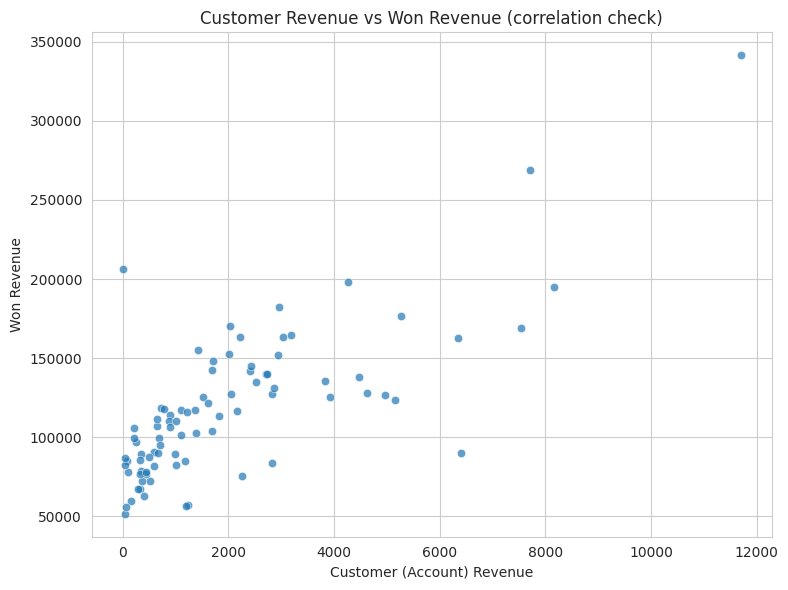

In [65]:
# Account size vs won revenue -- correlation, with both Pearson and Spearman as a robustness check
account_corr = account_performance[["account_revenue", "won_revenue"]].dropna()
pearson_r = account_corr.corr(method="pearson").iloc[0, 1]
spearman_r = account_corr.corr(method="spearman").iloc[0, 1]

print(f"Pearson correlation (account revenue vs won revenue):  {pearson_r:.3f}")
print(f"Spearman correlation (account revenue vs won revenue): {spearman_r:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=account_corr, x="account_revenue", y="won_revenue", alpha=0.7)
plt.title("Customer Revenue vs Won Revenue (correlation check)")
plt.xlabel("Customer (Account) Revenue")
plt.ylabel("Won Revenue")
plt.tight_layout()
plt.show()

## Part 5 — Key EDA Findings

1. **Overall performance:** 8,800 opportunities, 6,711 closed, a 63.15% closed win rate, and $10.01M in won revenue from 4,238 Won deals.
2. **Product:** GTX Pro is the largest revenue contributor; the highest win rate (MG Special) and the highest revenue product are not the same product — volume, conversion, and deal value must be read together.
3. **Region:** West leads on both won revenue and win rate; Central carries the largest volume but the weakest conversion, making its conversion pattern worth further investigation.
4. **Sales cycle:** the shortest cycles (1–14 days) convert worst; win rate varies by cycle length, with 15–30 day and 91+ day cycles showing the highest observed rates. This is an association, not an established causal driver.
5. **Customer concentration:** the top 10 accounts contribute 20.72% of account-attributed Won Revenue (top 5: 12.09%), describing the observed revenue share of the largest account-level contributors in this dataset.
6. **Account size vs revenue:** account revenue and won revenue are positively correlated (**Pearson r = 0.756, Spearman ρ = 0.723**) — larger customers tend to generate more won revenue, and the relationship is not solely driven by outliers, since the rank-based Spearman estimate is close to the linear Pearson estimate.

---
# Part 6 — SQL Analysis & Validation

**Business question:** Do the headline findings hold up in an independent query layer, built without reusing any pandas code?

The queries below are the executed form of `business_analysis_queries.sql` (included in this repository), run here against an in-memory SQLite database built from the cleaned tables, so the notebook is self-contained and the SQL file stays runnable on its own against the same data.

In [66]:
import sqlite3

conn = sqlite3.connect(":memory:")

pd.read_csv("sales_pipeline_clean.csv").to_sql("sales_pipeline", conn, index=False, if_exists="replace")
pd.read_csv("accounts_clean.csv").to_sql("accounts", conn, index=False, if_exists="replace")
pd.read_csv("products_clean.csv").to_sql("products", conn, index=False, if_exists="replace")
pd.read_csv("sales_teams_clean.csv").to_sql("sales_teams", conn, index=False, if_exists="replace")

pd.read_sql("SELECT COUNT(*) AS row_count FROM sales_pipeline", conn)

,row_count
0,8800


In [67]:
with open("business_analysis_queries.sql") as f:
    sql_script = f.read()

# Split into individual queries on the "-- QUERY NN" section markers
import re
raw_chunks = re.split(r"-- ={5,}\n-- QUERY \d+.*?-- ={5,}", sql_script, flags=re.DOTALL)
queries = [q.strip(" \n-") for q in raw_chunks if q.strip(" \n-")][1:]  # drop the file header block

assert len(queries) == 11, f"Expected 11 queries, parsed {len(queries)} -- check business_analysis_queries.sql formatting"
print(f"Parsed {len(queries)} SQL queries from business_analysis_queries.sql")

Parsed 11 SQL queries from business_analysis_queries.sql


### Query 01 — Total Opportunities

In [68]:
pd.read_sql(queries[0], conn)

,total_opportunities
0,8800


### Query 02 — Deal Stage Distribution

In [69]:
pd.read_sql(queries[1], conn)

,deal_stage,opportunities
0,Won,4238
1,Lost,2473
2,Engaging,1589
3,Prospecting,500


### Query 03 — Won Revenue

In [70]:
pd.read_sql(queries[2], conn)

,won_revenue
0,10005534.0


### Query 04 — Closed Win Rate

In [71]:
pd.read_sql(queries[3], conn)

,closed_win_rate_pct
0,63.15


### Query 05 — Product Performance

In [72]:
pd.read_sql(queries[4], conn)

,product,opportunities,won_opportunities,lost_opportunities,win_rate_pct,won_revenue
0,GTX Pro,1480,729,418,63.56,3510578.0
1,GTX Plus Pro,968,479,266,64.30,2629651.0
2,MG Advanced,1412,654,430,60.33,2216387.0
3,GTX Plus Basic,1383,653,398,62.13,705275.0
4,GTX Basic,1866,915,521,63.72,499263.0
5,GTK 500,40,15,10,60.00,400612.0
6,MG Special,1651,793,430,64.84,43768.0


### Query 06 — Sales Agent Performance

In [73]:
pd.read_sql(queries[5], conn).head(10)

,sales_agent,opportunities,won_opportunities,lost_opportunities,win_rate_pct,won_revenue
0,Darcel Schlecht,747,349,204,63.11,1153214.0
1,Vicki Laflamme,451,221,126,63.69,478396.0
2,Kary Hendrixson,438,209,126,62.39,454298.0
3,Cassey Cress,346,163,98,62.45,450489.0
4,Donn Cantrell,275,158,117,57.45,445860.0
5,Reed Clapper,237,155,82,65.40,438336.0
6,Zane Levy,349,161,100,61.69,430068.0
7,Corliss Cosme,310,150,79,65.50,421036.0
8,James Ascencio,267,135,71,65.53,413533.0
9,Daniell Hammack,259,114,73,60.96,364229.0


### Query 07 — Regional Performance

In [74]:
pd.read_sql(queries[6], conn)

,regional_office,opportunities,won_opportunities,lost_opportunities,win_rate_pct,won_revenue
0,West,2997,1438,811,63.94,3568647.0
1,Central,3512,1629,975,62.56,3346293.0
2,East,2291,1171,687,63.02,3090594.0


### Query 08 — Sector Performance

In [75]:
pd.read_sql(queries[7], conn)

,sector,opportunities,won_opportunities,lost_opportunities,win_rate_pct,won_revenue
0,retail,1397,799,468,63.06,1867528.0
1,technology,1165,671,387,63.42,1515487.0
2,medical,1051,592,358,62.32,1359595.0
3,software,757,450,254,63.92,1077934.0
4,finance,678,375,238,61.17,950908.0
5,marketing,674,404,219,64.85,922321.0
6,entertainment,451,260,142,64.68,689007.0
7,telecommunications,501,285,171,62.50,653574.0
8,services,390,223,129,63.35,533006.0
9,employment,311,179,107,62.59,436174.0


### Query 09 — Quarterly Performance

In [76]:
pd.read_sql(queries[8], conn)

,close_quarter,won_opportunities,lost_opportunities,win_rate_pct
0,2017Q1,531,116,82.07
1,2017Q2,1254,778,61.71
2,2017Q3,1257,790,61.41
3,2017Q4,1196,789,60.25


### Query 10 — Sales-Cycle Analysis

In [77]:
pd.read_sql(queries[9], conn)

,sales_cycle_group,opportunities,won_opportunities,lost_opportunities,win_rate_pct
0,1-14 days,2806,1557,1249,55.49
1,15-30 days,357,260,97,72.83
2,31-60 days,569,377,192,66.26
3,61-90 days,1621,1078,543,66.50
4,91+ days,1358,966,392,71.13


### Query 11 — Top Customer Accounts

In [78]:
pd.read_sql(queries[10], conn)

,account,sector,office_location,opportunities,won_opportunities,won_revenue
0,Kan-code,software,United States,196,115,341455.0
1,Konex,technology,United States,178,108,269245.0
2,Condax,medical,United States,170,105,206410.0
3,Cheers,entertainment,United States,98,57,198020.0
4,Hottechi,technology,Korea,200,111,194957.0
5,Goodsilron,marketing,United States,95,65,182522.0
6,Treequote,telecommunications,United States,116,65,176751.0
7,Warephase,services,United States,106,70,170046.0
8,Xx-holding,finance,United States,87,48,169357.0
9,Isdom,medical,United States,119,65,164683.0


### Cross-Validation: SQL vs Python

In [79]:
sql_total = pd.read_sql("SELECT COUNT(*) AS n FROM sales_pipeline", conn)["n"][0]
sql_won_revenue = pd.read_sql("SELECT SUM(close_value) AS r FROM sales_pipeline WHERE deal_stage='Won'", conn)["r"][0]
sql_win_rate_query = (
    "SELECT 100.0 * SUM(CASE WHEN deal_stage='Won' THEN 1 ELSE 0 END) "
    "/ NULLIF(SUM(CASE WHEN deal_stage IN ('Won','Lost') THEN 1 ELSE 0 END), 0) AS wr "
    "FROM sales_pipeline"
)
sql_win_rate = pd.read_sql(sql_win_rate_query, conn)["wr"][0]

validation = pd.DataFrame({
    "Metric": ["Total Opportunities", "Won Revenue", "Closed Win Rate (%)"],
    "Python (Part 4)": [total_opportunities, round(won_revenue, 2), round(win_rate * 100, 2)],
    "SQL (Part 6)": [sql_total, round(sql_won_revenue, 2), round(sql_win_rate, 2)],
})
validation["Match"] = np.isclose(
    validation["Python (Part 4)"].astype(float), validation["SQL (Part 6)"].astype(float)
)
validation

,Metric,Python (Part 4),SQL (Part 6),Match
0,Total Opportunities,8800.00,8800.00,True
1,Won Revenue,10005534.00,10005534.00,True
2,Closed Win Rate (%),63.15,63.15,True


**Result:** all three headline metrics match exactly between the independently-written Python and SQL implementations, confirming the KPI definitions from Part 4 are applied consistently across both layers.

---
# Part 7 — Interactive Dashboard (Data Studio)

**Business question:** How can these findings be made available for ongoing, self-serve exploration rather than a one-time notebook read?

The KPIs and breakdowns above are published as a live Data Studio dashboard (formerly branded Looker Studio; Google renamed it back to Data Studio in April 2026 — the link and sharing permissions carried over automatically), so stakeholders can filter by product, region, sector, and time period without touching this notebook:

**[View the Interactive Data Studio Dashboard](https://datastudio.google.com/reporting/435ae8a1-4d90-4e4c-b870-f5b9d04d6987)**

A static snapshot is also included in this repository as `dashboard.pdf`. The dashboard's panels are: headline KPIs (total/won/lost/open opportunities, won revenue, closed win rate), won revenue over time, pipeline status breakdown, won revenue by product, closed win rate by region, top sales agents, win rate by sales-cycle length, and won revenue by sector — all built from the same definitions established in Part 4.

The cell below produces the flat extract (`looker_dashboard_data.csv`) that feeds the dashboard, so the published numbers are traceable back to this notebook.

In [80]:
dashboard_columns = [
    "opportunity_id", "deal_stage", "pipeline_status", "engage_date", "close_date", "close_value",
    "sales_agent", "manager", "regional_office", "product", "series", "sales_price",
    "account", "sector", "account_revenue", "employees", "office_location",
    "won_flag", "lost_flag", "open_flag", "sales_cycle_days",
    "engage_year", "engage_quarter", "close_year", "close_quarter",
]

dashboard_extract = master[dashboard_columns].copy()
dashboard_extract.to_csv("looker_dashboard_data.csv", index=False)
print("Dashboard extract saved:", dashboard_extract.shape)

Dashboard extract saved: (8800, 25)


In [81]:
# Validate the extract reproduces the same headline KPIs used to build the dashboard
check_won_revenue = dashboard_extract.loc[dashboard_extract["deal_stage"] == "Won", "close_value"].sum()
check_win_rate = dashboard_extract["won_flag"].sum() / (dashboard_extract["won_flag"].sum() + dashboard_extract["lost_flag"].sum()) * 100

print(f"Dashboard-extract Won Revenue: ${check_won_revenue:,.2f}  (Part 4 value: ${won_revenue:,.2f})")
print(f"Dashboard-extract Win Rate:    {check_win_rate:.2f}%      (Part 4 value: {win_rate*100:.2f}%)")

Dashboard-extract Won Revenue: $10,005,534.00  (Part 4 value: $10,005,534.00)
Dashboard-extract Win Rate:    63.15%      (Part 4 value: 63.15%)


**Result:** the dashboard extract reproduces the Part 4 KPIs exactly, confirming the Data Studio dashboard, this notebook, and the SQL validation layer are all built from one consistent set of definitions.

---
# Part 8 — Executive Summary, Recommendations & Limitations

## Headline Metrics

| Metric | Value |
|---|---|
| Total Opportunities | 8,800 |
| Won / Lost / Open | 4,238 / 2,473 / 2,089 |
| Closed Win Rate | 63.15% |
| Won Revenue | $10.01M |
| Average / Median Won Deal | $2,360.91 / $1,117 |
| Average / Median Sales Cycle (closed) | 47.99 / 45 days |

## Observed Findings (evidence-based, directly from the data)

- Revenue is right-skewed: a small number of large deals lift the average well above the median deal size.
- Product performance is multi-dimensional — the highest-volume, highest-win-rate, and highest-revenue products are all different (Section 5.2).
- West leads the three regions in Won Revenue and Closed Win Rate; Central has the largest volume but the lowest win rate (Section 5.3).
- Among accounts with linked account data, the top 10 account-level contributors represent 20.72% of account-attributed Won Revenue, and the highest Won-Revenue quartile shows the highest average win rate and average won-deal size (Section 5.4).
- Short sales cycles (1–14 days) have the lowest win rate, while 15–30 day and 91+ day cycles have the highest observed win rates (Section 5.5).
- Won revenue and customer size are positively correlated (Pearson r = 0.756, Spearman ρ = 0.723) — a moderately strong, robust association (Section 5.6).

## Interpretation (our reading of the findings — reasonable, but not the only possible reading)

- Central's lower win rate warrants investigation into conversion drivers; the dataset cannot distinguish coaching, deal mix, territory effects, or other causes.
- The short-cycle / low-win-rate pattern is consistent with fast, low-friction deals being resolved quickly, but we cannot confirm the mechanism without stage-transition timestamps (see Limitations).
- MG Special's high win rate and negligible revenue suggest it **may** function as a low-friction "foot in the door" product rather than a revenue driver in its own right; this is a hypothesis, not a directly observed product role.

## Recommendations (actions implied by the above — for business stakeholders to weigh, not directives)

1. **Investigate Central-region conversion drivers.** Central has the largest pipeline (3,512 opportunities) and the lowest win rate (62.6%) of the three regions; examine deal mix, product mix, account mix, and operating practices before attributing the gap to any single cause.
2. **Study the operational differences behind West's performance.** West leads on both Won Revenue and win rate; reviewing qualification, account targeting, product mix, and manager practices could identify practices worth testing elsewhere, rather than assuming they should be replicated unchanged.
3. **Re-evaluate GTX Basic and MG Special's role in the portfolio.** Both drive volume but modest revenue-per-deal; consider whether they are effective as entry-point or upsell-path products rather than judging them on standalone revenue alone.
4. **Instrument the CRM to capture stage-transition timestamps**, not just engage/close dates; this would materially strengthen sales-cycle analysis by allowing the business to test where time is spent and how stage progression relates to outcomes.

## Limitations & Assumptions

- **Partial Q1 2017 window:** engagement data starts October 2016, so very few opportunities had time to close in Q1 2017. Q1 2017 figures are not comparable to the fuller Q2–Q4 2017 quarters and should be read as a ramp-up period, not a performance dip.
- **No stage-transition history:** the source data provides only `engage_date` and `close_date` per opportunity, not timestamps for intermediate stage changes. Sales-cycle analysis (Section 5.5) measures total time-to-close, not time spent in any individual stage, and cannot isolate where in the process time is actually lost.
- **Account coverage:** 16.2% of opportunities (1,425 of 8,800) have no linked account and are therefore excluded from all account- and sector-level breakdowns (Section 5.4), though they remain fully included in every pipeline-level and product-level KPI.
- **`subsidiary_of` is unused:** 85.3% missing, and not analytically meaningful at that level of missingness.
- **Correlation, not causation:** the account-size/revenue correlation (Section 5.6) and the cycle-length/win-rate pattern (Section 5.5) are associations. Neither this notebook nor the underlying data can establish a causal mechanism.
- **Manual typo correction:** the two source-data typos found in Part 1 (`"GTXPro"`, `"technolgy"`) were corrected explicitly; any other unseen data-entry variants would not be caught by this process.
- **Single ~14-month window:** the data covers October 2016–December 2017 only. Findings describe this period and should not be assumed to generalize to other years without re-validation.

## Suggested Next Steps

- Segment the sales-cycle analysis by product and region jointly (partially explored in Section 5.6) to see whether the cycle-length/win-rate pattern holds within, not just across, product lines.
- Bring in a second year of data, if available, to test whether the West-region and Central-region patterns persist or were specific to this window.
- Pair this analysis with agent-level activity data (call/email volume, if captured) to test the "fast deals fail fast" interpretation directly, rather than inferring it from cycle length alone.